In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


In [2]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(PROC / "cleaned_apple_sales_enriched.csv")

In [3]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,sales_amount,invalid_launch_flag,product_age_days,gdp,exchange_rate,inflation_rate,internet_usage_pct,country_norm,country_norm_mapped,year
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,976,True,0,6985.643939,31.293673,-0.845937,77.8437,thailand,thailand,2020
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,6461,True,0,40028.734170,106.774582,-0.024996,90.2195,japan,japan,2020
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,3416,True,0,64401.507440,1.000000,1.233584,90.3447,united states,united states,2020
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,923,True,0,48716.409890,0.875506,1.381911,87.5294,austria,austria,2020
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,15957,True,0,8841.270751,21.485608,3.396834,71.4902,mexico,mexico,2020


In [4]:
df['gdp'].unique()

array([6.98564394e+03, 4.00287342e+04, 6.44015074e+04, 4.87164099e+04,
       8.84127075e+03, 2.72339427e+04, 3.71738754e+04, 1.06274638e+04,
       5.34679277e+04, 4.04048062e+04, 6.76900000e+11, 6.14100793e+04,
       3.17212989e+04, 5.17915402e+04, 5.33968711e+03, 4.35378393e+04,
       3.91698606e+04, 4.73797652e+04, 3.20914867e+04, 1.28874357e+04,
       4.33600211e+04, 5.22656542e+04, 8.00561288e+04, 7.13074017e+04,
       6.01419881e+04, 6.06077789e+04, 5.28866616e+04, 7.05720755e+03,
       6.22262164e+03, 3.68525425e+04, 1.03140507e+04, 4.69264757e+04,
       7.76900000e+11, 4.37251000e+04, 4.00945600e+04, 3.51255225e+04,
       3.07994776e+04, 5.36487191e+04, 5.62568007e+04, 5.91233186e+04,
       6.49970137e+04, 3.02702687e+04, 4.98990653e+04, 7.78609113e+04,
       9.02990695e+04, 4.60629914e+04, 1.29706056e+04, 6.90935282e+03,
       1.14021410e+04, 4.10828119e+04, 3.40656439e+04, 6.68044507e+03,
       3.23946834e+04, 4.96861155e+04, 5.21766649e+04, 3.56539042e+04,
      

In [5]:
df['gdp'].describe()


count    1.040200e+06
mean     1.907144e+10
std      1.549602e+11
min      5.339687e+03
25%      3.383618e+04
50%      4.920081e+04
75%      6.457201e+04
max      1.869700e+12
Name: gdp, dtype: float64

In [6]:
df.sort_values('gdp', ascending=False).head(10)


,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,sales_amount,invalid_launch_flag,product_age_days,gdp,exchange_rate,inflation_rate,internet_usage_pct,country_norm,country_norm_mapped,year
1040138,HQ-15003,2024-11-12,ST-71,P-9,5,MacBook Pro (Touch Bar),2024-06-17,1304,Apple Yeouido,Seoul,...,6520,False,148,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
893834,RH-03176,2024-03-07,ST-71,P-53,1,Apple Watch Series 5,2023-11-10,1296,Apple Yeouido,Seoul,...,1296,False,118,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
893805,IW-0153,2024-03-07,ST-70,P-23,6,iPad (9th Generation),2022-03-08,1949,Apple Gangnam,Seoul,...,11694,False,730,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
1040075,PJ-161238,2024-11-12,ST-71,P-14,6,AirPods Pro (2nd Generation),2021-01-29,696,Apple Yeouido,Seoul,...,4176,False,1383,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
1040034,OI-947766,2024-11-12,ST-70,P-45,8,Apple Watch Series 9,2020-09-12,1014,Apple Gangnam,Seoul,...,8112,False,1522,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
893794,VB-96996,2024-03-07,ST-70,P-60,3,iMac with Retina Display,2020-07-24,343,Apple Gangnam,Seoul,...,1029,False,1322,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
918450,RJ-90927,2024-04-18,ST-71,P-44,1,iPhone 12 Pro Max,2020-09-09,544,Apple Yeouido,Seoul,...,544,False,1317,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
918306,IC-329999,2024-04-18,ST-70,P-9,9,MacBook Pro (Touch Bar),2020-01-01,1304,Apple Gangnam,Seoul,...,11736,True,1569,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
918309,KB-96957,2024-04-18,ST-70,P-66,10,Mac Mini (M2),2021-10-30,874,Apple Gangnam,Seoul,...,8740,False,901,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
918477,YY-879356,2024-04-18,ST-71,P-55,1,Apple TV HD,2021-11-24,1258,Apple Yeouido,Seoul,...,1258,False,876,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024


In [7]:
import numpy as np

# أكبر قيمة
print("Max GDP:", df['gdp'].max())

# عدد القيم اللي أكبر من 200 ألف
large_values = df[df['gdp'] > 200_000]
print("Count of suspicious large values:", large_values.shape[0])


Max GDP: 1869700000000.0
Count of suspicious large values: 18959


In [8]:
suspicious_countries = (
    df[df['gdp'] > 200_000]
    .groupby(['country_norm_mapped', 'year'])['gdp']
    .max()
    .reset_index()
    .sort_values('gdp', ascending=False)
)

print(suspicious_countries)


  country_norm_mapped  year           gdp
0         korea, rep.  2024  1.869700e+12
5              taiwan  2024  7.970000e+11
2              taiwan  2021  7.769000e+11
3              taiwan  2022  7.656000e+11
4              taiwan  2023  7.573000e+11
1              taiwan  2020  6.769000e+11


In [9]:
df['gdp_type'] = np.where(df['gdp'] > 200_000,
                          'GDP_total',
                          'GDP_per_capita')


In [10]:
df['gdp_type'].value_counts()


gdp_type
GDP_per_capita    1021241
GDP_total           18959
Name: count, dtype: int64

In [11]:
import pandas as pd

manual_gdp_pc = pd.DataFrame({
    "country_norm_mapped": ["korea, rep."]*5 + ["taiwan"]*5,
    "year": [2020,2021,2022,2023,2024]*2,
    "gdp_per_capita": [
        31728, 34998, 32394, 33147, 34000,  # Korea
        28371, 33775, 32756, 33907, 35000   # Taiwan
    ]
})

df = df.merge(
    manual_gdp_pc,
    on=["country_norm_mapped", "year"],
    how="left"
)

df['gdp_cleaned'] = df['gdp']

df.loc[df['gdp'] > 200_000, 'gdp_cleaned'] = df['gdp_per_capita']



In [12]:
df.columns  

Index(['sale_id', 'sale_date', 'store_id', 'product_id', 'quantity',
       'product_name', 'launch_date', 'price', 'store_name', 'city', 'country',
       'category_id', 'category_name', 'sales_amount', 'invalid_launch_flag',
       'product_age_days', 'gdp', 'exchange_rate', 'inflation_rate',
       'internet_usage_pct', 'country_norm', 'country_norm_mapped', 'year',
       'gdp_type', 'gdp_per_capita', 'gdp_cleaned'],
      dtype='object')

In [13]:
df[df['gdp_cleaned'] > 200_000].shape


(0, 26)

In [14]:
df['gdp_cleaned'].describe()


count    1.040200e+06
mean     4.680516e+04
std      2.361469e+04
min      5.339687e+03
25%      3.350901e+04
50%      4.904069e+04
75%      6.440748e+04
max      9.067407e+04
Name: gdp_cleaned, dtype: float64

In [15]:
df.isnull().sum()

sale_id                     0
sale_date                   0
store_id                    0
product_id                  0
quantity                    0
product_name                0
launch_date                 0
price                       0
store_name                  0
city                        0
country                     0
category_id                 0
category_name               0
sales_amount                0
invalid_launch_flag         0
product_age_days            0
gdp                         0
exchange_rate               0
inflation_rate              0
internet_usage_pct     106716
country_norm                0
country_norm_mapped         0
year                        0
gdp_type                    0
gdp_per_capita         998306
gdp_cleaned                 0
dtype: int64

In [16]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,gdp,exchange_rate,inflation_rate,internet_usage_pct,country_norm,country_norm_mapped,year,gdp_type,gdp_per_capita,gdp_cleaned
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,6985.643939,31.293673,-0.845937,77.8437,thailand,thailand,2020,GDP_per_capita,NaN,6985.643939
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,40028.734170,106.774582,-0.024996,90.2195,japan,japan,2020,GDP_per_capita,NaN,40028.734170
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,64401.507440,1.000000,1.233584,90.3447,united states,united states,2020,GDP_per_capita,NaN,64401.507440
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,48716.409890,0.875506,1.381911,87.5294,austria,austria,2020,GDP_per_capita,NaN,48716.409890
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,8841.270751,21.485608,3.396834,71.4902,mexico,mexico,2020,GDP_per_capita,NaN,8841.270751


In [17]:
df['gdp_per_capita'] = df['gdp_cleaned']


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 26 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   sale_id              1040200 non-null  object 
 1   sale_date            1040200 non-null  object 
 2   store_id             1040200 non-null  object 
 3   product_id           1040200 non-null  object 
 4   quantity             1040200 non-null  int64  
 5   product_name         1040200 non-null  object 
 6   launch_date          1040200 non-null  object 
 7   price                1040200 non-null  int64  
 8   store_name           1040200 non-null  object 
 9   city                 1040200 non-null  object 
 10  country              1040200 non-null  object 
 11  category_id          1040200 non-null  object 
 12  category_name        1040200 non-null  object 
 13  sales_amount         1040200 non-null  int64  
 14  invalid_launch_flag  1040200 non-null  bool   
 15

In [19]:
df.isnull().sum()

sale_id                     0
sale_date                   0
store_id                    0
product_id                  0
quantity                    0
product_name                0
launch_date                 0
price                       0
store_name                  0
city                        0
country                     0
category_id                 0
category_name               0
sales_amount                0
invalid_launch_flag         0
product_age_days            0
gdp                         0
exchange_rate               0
inflation_rate              0
internet_usage_pct     106716
country_norm                0
country_norm_mapped         0
year                        0
gdp_type                    0
gdp_per_capita              0
gdp_cleaned                 0
dtype: int64

In [20]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,gdp,exchange_rate,inflation_rate,internet_usage_pct,country_norm,country_norm_mapped,year,gdp_type,gdp_per_capita,gdp_cleaned
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,6985.643939,31.293673,-0.845937,77.8437,thailand,thailand,2020,GDP_per_capita,6985.643939,6985.643939
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,40028.734170,106.774582,-0.024996,90.2195,japan,japan,2020,GDP_per_capita,40028.734170,40028.734170
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,64401.507440,1.000000,1.233584,90.3447,united states,united states,2020,GDP_per_capita,64401.507440,64401.507440
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,48716.409890,0.875506,1.381911,87.5294,austria,austria,2020,GDP_per_capita,48716.409890,48716.409890
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,8841.270751,21.485608,3.396834,71.4902,mexico,mexico,2020,GDP_per_capita,8841.270751,8841.270751


In [21]:
df.describe()

,quantity,price,sales_amount,product_age_days,gdp,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita,gdp_cleaned
count,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,933484.000000,1.040200e+06,1.040200e+06,1.040200e+06
mean,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.907144e+10,1.542778e+02,3.247802e+00,89.942721,2.021946e+03,4.680516e+04,4.680516e+04
std,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,1.549602e+11,6.699082e+02,2.625053e+00,7.678001,1.393893e+00,2.361469e+04,2.361469e+04
min,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,5.339687e+03,7.270649e-01,-2.079403e+00,69.795300,2.020000e+03,5.339687e+03,5.339687e+03
25%,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,3.383618e+04,1.000000e+00,1.233584e+00,86.981500,2.021000e+03,3.350901e+04,3.350901e+04
50%,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,4.920081e+04,1.349909e+00,2.863910e+00,92.000000,2.022000e+03,4.904069e+04,4.904069e+04
75%,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,6.457201e+04,7.083998e+00,4.878357e+00,94.693500,2.023000e+03,6.440748e+04,6.440748e+04
max,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,1.869700e+12,4.325955e+03,1.173590e+01,100.000000,2.024000e+03,9.067407e+04,9.067407e+04


In [22]:
df.drop(columns=['gdp', 'gdp_cleaned'], inplace=True)


In [23]:
df.drop(columns=['country', 'country_norm'], inplace=True)


In [24]:
df.describe()

,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita
count,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,933484.000000,1.040200e+06,1.040200e+06
mean,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,89.942721,2.021946e+03,4.680516e+04
std,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.678001,1.393893e+00,2.361469e+04
min,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,69.795300,2.020000e+03,5.339687e+03
25%,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,86.981500,2.021000e+03,3.350901e+04
50%,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,92.000000,2.022000e+03,4.904069e+04
75%,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,94.693500,2.023000e+03,6.440748e+04
max,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,100.000000,2.024000e+03,9.067407e+04


In [25]:
df['internet_usage_pct'] = df.groupby(
    ['country_norm_mapped', 'year']
)['internet_usage_pct'].transform(
    lambda x: x.fillna(x.mean())
)


In [26]:
df['internet_usage_pct'] = df.groupby(
    'country_norm_mapped'
)['internet_usage_pct'].transform(
    lambda x: x.fillna(x.mean())
)


In [27]:
df.isna().sum()

sale_id                0
sale_date              0
store_id               0
product_id             0
quantity               0
product_name           0
launch_date            0
price                  0
store_name             0
city                   0
category_id            0
category_name          0
sales_amount           0
invalid_launch_flag    0
product_age_days       0
exchange_rate          0
inflation_rate         0
internet_usage_pct     0
country_norm_mapped    0
year                   0
gdp_type               0
gdp_per_capita         0
dtype: int64

In [28]:
df.describe()

,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita
count,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04
std,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04
min,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03
25%,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04
50%,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04
75%,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04
max,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04


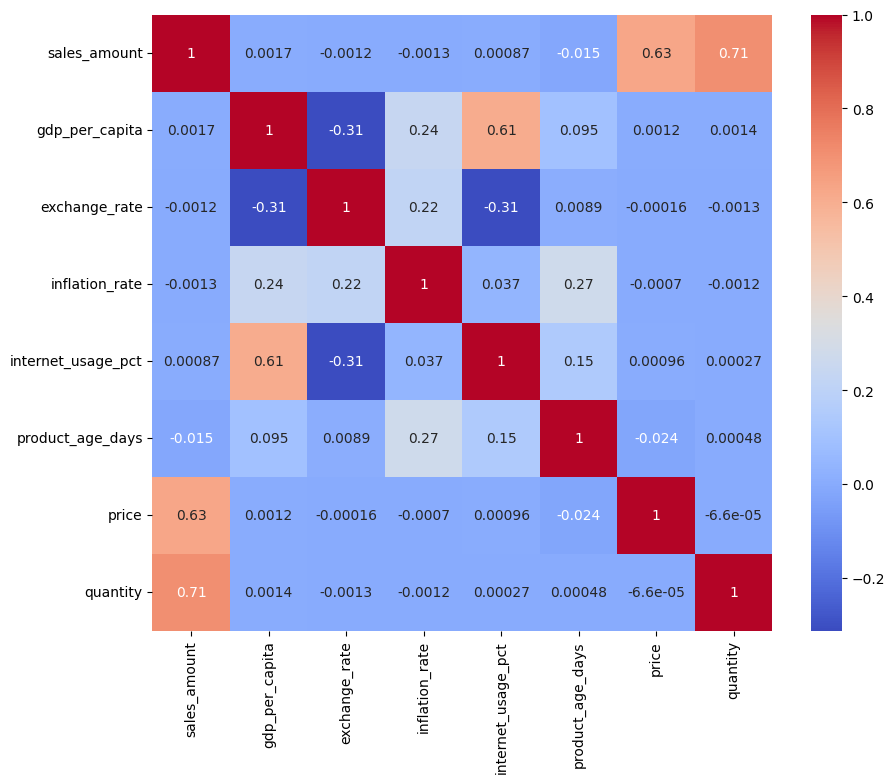

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(
    df[['sales_amount','gdp_per_capita','exchange_rate',
        'inflation_rate','internet_usage_pct',
        'product_age_days','price','quantity']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()


In [30]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 22 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   sale_id              1040200 non-null  object 
 1   sale_date            1040200 non-null  object 
 2   store_id             1040200 non-null  object 
 3   product_id           1040200 non-null  object 
 4   quantity             1040200 non-null  int64  
 5   product_name         1040200 non-null  object 
 6   launch_date          1040200 non-null  object 
 7   price                1040200 non-null  int64  
 8   store_name           1040200 non-null  object 
 9   city                 1040200 non-null  object 
 10  category_id          1040200 non-null  object 
 11  category_name        1040200 non-null  object 
 12  sales_amount         1040200 non-null  int64  
 13  invalid_launch_flag  1040200 non-null  bool   
 14  product_age_days     1040200 non-null  int64  
 15

,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita
count,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04
std,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04
min,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03
25%,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04
50%,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04
75%,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04
max,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04


In [31]:
df.sample(50)

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,sales_amount,invalid_launch_flag,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,country_norm_mapped,year,gdp_type,gdp_per_capita
156448,LS-960439,2020-09-24,ST-39,P-16,9,Beats Studio Buds,2020-01-01,762,Apple Taipei 101,Taipei,...,6858,True,267,29.500000,-0.200000,90.000000,taiwan,2020,GDP_total,28371.000000
550318,RE-5415,2022-07-29,ST-26,P-57,3,iMac 24-inch,2021-04-07,449,Apple Leidseplein,Amsterdam,...,1347,False,478,0.949624,10.001208,92.519700,netherlands,2022,GDP_per_capita,59123.318560
183079,IX-637898,2020-11-08,ST-43,P-48,10,Apple Watch Nike Edition,2020-06-24,884,Apple Cotai Central,Macau,...,8840,False,137,6.900767,2.419422,70.052800,china,2020,GDP_per_capita,10627.463800
69142,KR-292386,2020-04-28,ST-14,P-43,9,iPhone 12 Pro,2020-01-01,1342,Apple The Americana at Brand,Glendale,...,12078,True,118,1.000000,1.233584,90.344700,united states,2020,GDP_per_capita,64401.507440
147443,PT-16321,2020-09-09,ST-45,P-78,5,Magic Mouse,2020-01-01,313,Apple Jewel Changi Airport,Singapore,...,1565,True,252,1.379742,-0.172112,92.004300,singapore,2020,GDP_per_capita,61410.079260
732384,UB-09847,2023-06-06,ST-24,P-51,6,Apple Watch Series 7,2020-01-13,1431,Apple Kurfuerstendamm,Berlin,...,8586,False,1240,0.924840,5.946437,92.476400,germany,2023,GDP_per_capita,53940.407340
297159,QR-143156,2021-05-22,ST-38,P-61,8,Mac Pro (2023),2020-01-01,681,Apple Taikoo Li,Chengdu,...,5448,True,507,6.448975,0.981015,73.053200,china,2021,GDP_per_capita,12887.435720
735124,IG-0293,2023-06-10,ST-31,P-16,5,Beats Studio Buds,2020-01-01,762,Apple Shinjuku,Tokyo,...,3810,True,1256,140.491100,3.268134,86.981500,japan,2023,GDP_per_capita,33836.175630
726665,GV-33778,2023-05-27,ST-10,P-33,5,iPhone 14 Plus,2020-01-01,1259,Apple South Coast Plaza,Costa Mesa,...,6295,True,1242,1.000000,4.116338,93.144400,united states,2023,GDP_per_capita,82304.620430
8127,FK-8939,2020-01-15,ST-9,P-27,1,iPad Air (4th Generation),2020-01-01,952,Apple Park Visitor Center,Cupertino,...,952,True,14,1.000000,1.233584,90.344700,united states,2020,GDP_per_capita,64401.507440


In [32]:
import numpy as np
import pandas as pd

np.random.seed(42)

df = df.copy()
df['sale_date'] = pd.to_datetime(df['sale_date'])

# =====================================================
# 1️⃣ Seasonal Factor
# =====================================================

def seasonal_multiplier(month):
    if month == 11:
        return 1.3
    elif month == 12:
        return 1.5
    elif month == 1:
        return 0.8
    else:
        return 1.0

df['season_factor'] = df['sale_date'].dt.month.apply(seasonal_multiplier)

# =====================================================
# 2️⃣ Economic Factor
# =====================================================

df['economic_factor'] = (
    (df['gdp_per_capita'] / df['gdp_per_capita'].mean()) *
    (1 - df['inflation_rate'] / 100)
)

df['economic_factor'] = df['economic_factor'].clip(0.5, 1.5)

# =====================================================
# 3️⃣ Promotion
# =====================================================

df['promo_flag'] = np.random.choice([0,1], size=len(df), p=[0.9,0.1])
df['promo_factor'] = np.where(df['promo_flag']==1, 1.4, 1.0)

# =====================================================
# 4️⃣ Dynamic Pricing
# =====================================================

# base price inflation adjustment
df['price_realistic'] = (
    df['price'] *
    (1 + df['inflation_rate']/100)
)

# promotion discount
df.loc[df['promo_flag']==1, 'price_realistic'] *= 0.85

# small random volatility
df['price_realistic'] *= np.random.normal(1, 0.03, len(df))

# =====================================================
# 5️⃣ Product Trend (Lifecycle Simulation)
# =====================================================

df['days_from_start'] = (df['sale_date'] - df['sale_date'].min()).dt.days

product_trend_map = {
    pid: np.random.uniform(-0.0005, 0.0008)
    for pid in df['product_id'].unique()
}

df['product_trend'] = df['product_id'].map(product_trend_map)

df['trend_factor'] = 1 + df['product_trend'] * df['days_from_start']
df['trend_factor'] = df['trend_factor'].clip(0.5, 1.8)

# =====================================================
# 6️⃣ Store Heterogeneity
# =====================================================

store_effect_map = {
    sid: np.random.normal(1, 0.15)
    for sid in df['store_id'].unique()
}

df['store_factor'] = df['store_id'].map(store_effect_map)
df['store_factor'] = df['store_factor'].clip(0.6, 1.5)

# =====================================================
# 7️⃣ Base Mean Demand
# =====================================================

df['mu_demand'] = (
    df['quantity'] *
    df['season_factor'] *
    df['economic_factor'] *
    df['promo_factor'] *
    df['trend_factor'] *
    df['store_factor']
)

df['mu_demand'] = df['mu_demand'].clip(lower=0.1)

# =====================================================
# 8️⃣ Price Elasticity
# =====================================================

elasticity = -0.8

price_change_ratio = (
    (df['price_realistic'] - df['price']) / df['price']
)

df['mu_demand'] *= (1 + elasticity * price_change_ratio)
df['mu_demand'] = df['mu_demand'].clip(lower=0.1)

# =====================================================
# 9️⃣ Shock Event (مثلاً أزمة 2022)
# =====================================================

shock_mask = (
    (df['sale_date'] >= '2022-03-01') &
    (df['sale_date'] <= '2022-06-01')
)

df.loc[shock_mask, 'mu_demand'] *= 0.7

# =====================================================
# 🔟 Negative Binomial Demand Generation
# =====================================================

k = 1.8  # dispersion parameter

p = k / (k + df['mu_demand'])
r = k

df['quantity_realistic'] = np.random.negative_binomial(r, p)

# =====================================================
# 1️⃣1️⃣ Zero Inflation
# =====================================================

zero_mask = np.random.choice([0,1], size=len(df), p=[0.97,0.03])
df.loc[zero_mask==1, 'quantity_realistic'] = 0

# =====================================================
# 1️⃣2️⃣ Final Sales
# =====================================================

df['sales_amount_realistic'] = (
    df['quantity_realistic'] *
    df['price_realistic']
)


In [33]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_flag,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,0,1.0,471.375260,0,0.000783,1.0,1.219421,1.002124,0,0.000000
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,1,1.4,754.811217,0,0.000154,1.0,1.172288,9.008169,2,1509.622434
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,0,1.0,520.297395,0,0.000783,1.0,0.958735,6.909914,11,5723.271345
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,0,1.0,986.821602,0,0.000692,1.0,1.109330,0.860548,0,0.000000
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,0,1.0,1754.958804,0,0.000495,1.0,1.203289,4.367104,4,7019.835216


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 34 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   sale_id                 1040200 non-null  object        
 1   sale_date               1040200 non-null  datetime64[ns]
 2   store_id                1040200 non-null  object        
 3   product_id              1040200 non-null  object        
 4   quantity                1040200 non-null  int64         
 5   product_name            1040200 non-null  object        
 6   launch_date             1040200 non-null  object        
 7   price                   1040200 non-null  int64         
 8   store_name              1040200 non-null  object        
 9   city                    1040200 non-null  object        
 10  category_id             1040200 non-null  object        
 11  category_name           1040200 non-null  object        
 12  sales_amount  

In [35]:
df.describe()

,sale_date,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita,...,promo_flag,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic
count,1040200,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,...,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,2022-06-07 16:51:18.598730752,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04,...,1.000038e-01,1.040002e+00,1.096057e+03,8.887023e+02,1.674567e-04,1.138149e+00,9.951873e-01,6.515001e+00,6.317707e+00,6.770804e+03
min,2020-01-01 00:00:00,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03,...,0.000000e+00,1.000000e+00,1.788246e+02,0.000000e+00,-4.962412e-04,5.000000e-01,6.442142e-01,1.233625e-01,0.000000e+00,0.000000e+00
25%,2021-03-20 00:00:00,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04,...,0.000000e+00,1.000000e+00,6.294309e+02,4.440000e+02,-1.429487e-04,9.299385e-01,8.603374e-01,2.549959e+00,1.000000e+00,9.643129e+02
50%,2022-06-07 00:00:00,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04,...,0.000000e+00,1.000000e+00,1.128185e+03,8.880000e+02,1.951382e-04,1.074579e+00,9.869100e-01,5.007457e+00,3.000000e+00,3.205011e+03
75%,2023-08-27 00:00:00,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04,...,0.000000e+00,1.000000e+00,1.492781e+03,1.334000e+03,4.945074e-04,1.372622e+00,1.133018e+00,8.831834e+00,8.000000e+00,8.254546e+03
max,2024-11-12 00:00:00,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04,...,1.000000e+00,1.400000e+00,2.427058e+03,1.777000e+03,7.993439e-04,1.800000e+00,1.469524e+00,8.070694e+01,2.600000e+02,3.662595e+05
std,NaN,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04,...,3.000053e-01,1.200021e-01,5.123379e+02,5.132911e+02,3.862175e-04,3.569842e-01,1.715577e-01,5.513714e+00,8.710648e+00,1.057133e+04


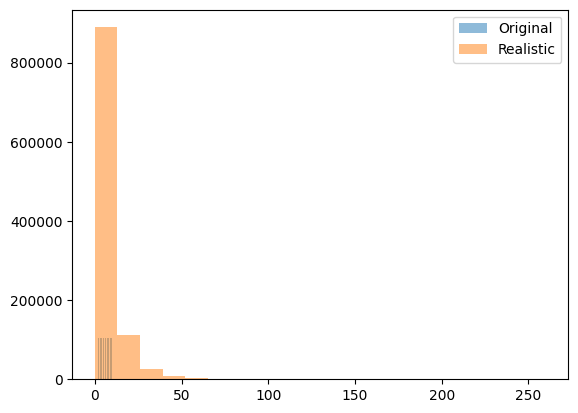

In [36]:
import matplotlib.pyplot as plt

plt.hist(df['quantity'], bins=20, alpha=0.5, label='Original')
plt.hist(df['quantity_realistic'], bins=20, alpha=0.5, label='Realistic')
plt.legend()
plt.show()


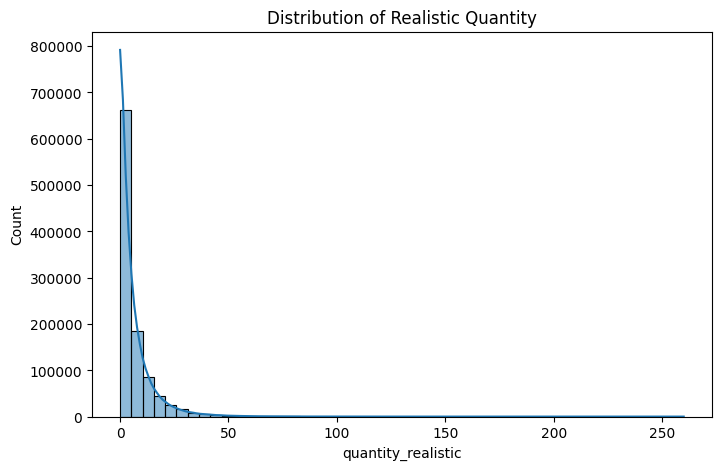

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['quantity_realistic'], bins=50, kde=True)
plt.title("Distribution of Realistic Quantity")
plt.show()


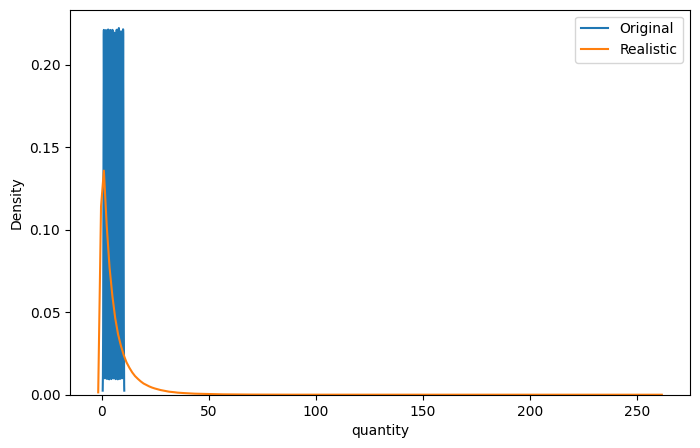

In [38]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['quantity'], label="Original")
sns.kdeplot(df['quantity_realistic'], label="Realistic")
plt.legend()
plt.show()


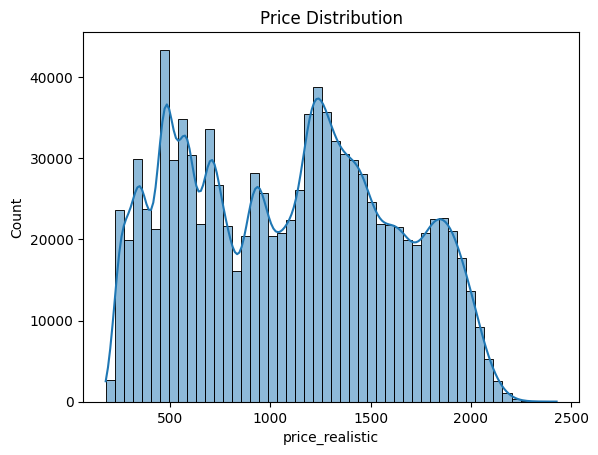

In [39]:
sns.histplot(df['price_realistic'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()


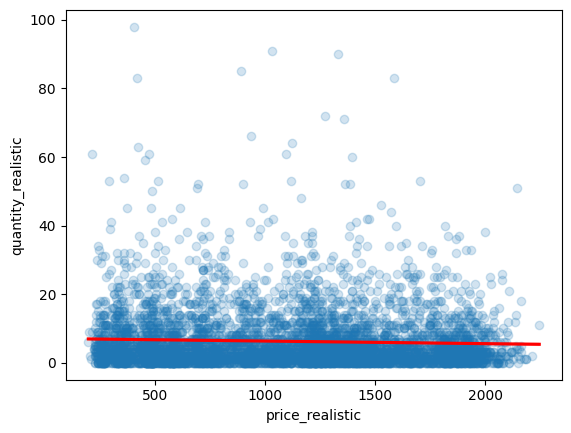

In [40]:
sns.regplot(x='price_realistic',
            y='quantity_realistic',
            data=df.sample(5000),
            scatter_kws={'alpha':0.2},
            line_kws={'color':'red'})
plt.show()


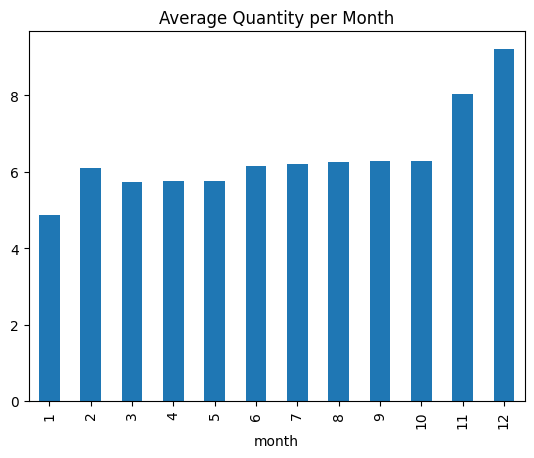

In [41]:
df['month'] = df['sale_date'].dt.month

monthly = df.groupby('month')['quantity_realistic'].mean()

monthly.plot(kind='bar')
plt.title("Average Quantity per Month")
plt.show()


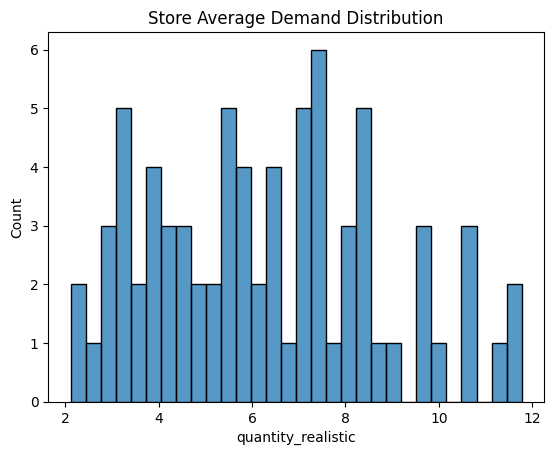

In [42]:
store_avg = df.groupby('store_id')['quantity_realistic'].mean()

sns.histplot(store_avg, bins=30)
plt.title("Store Average Demand Distribution")
plt.show()


<Axes: xlabel='sale_date'>

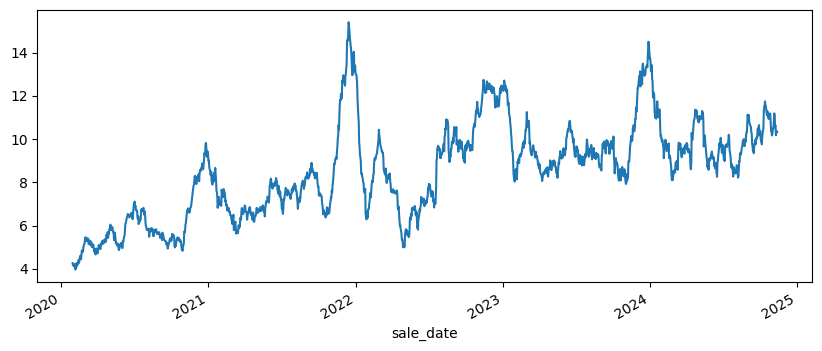

In [43]:
sample_product = df['product_id'].iloc[0]

df[df['product_id']==sample_product] \
    .groupby('sale_date')['quantity_realistic'] \
    .mean() \
    .rolling(30).mean() \
    .plot(figsize=(10,4))


In [44]:
# Filter for years 2020 to 2024 and calculate the overall total sum
total_sales = df[(df['year'] >= 2020) & (df['year'] <= 2024)]['sales_amount'].sum()

print(f"Total sales from 2020 to 2024: {total_sales:,.2f}")


Total sales from 2020 to 2024: 6,166,293,030.00


In [80]:
# Group by year to see the total sales for each individual year
yearly_sales = df[(df['year'] >= 2020) & (df['year'] <= 2024)].groupby('year')['sales_amount'].sum().reset_index()

print("Total Sales by Year:")
display(yearly_sales)


Total Sales by Year:


,year,sales_amount
0,2020,1269455486
1,2021,1264515755
2,2022,1269424007
3,2023,1261440123
4,2024,1101457659


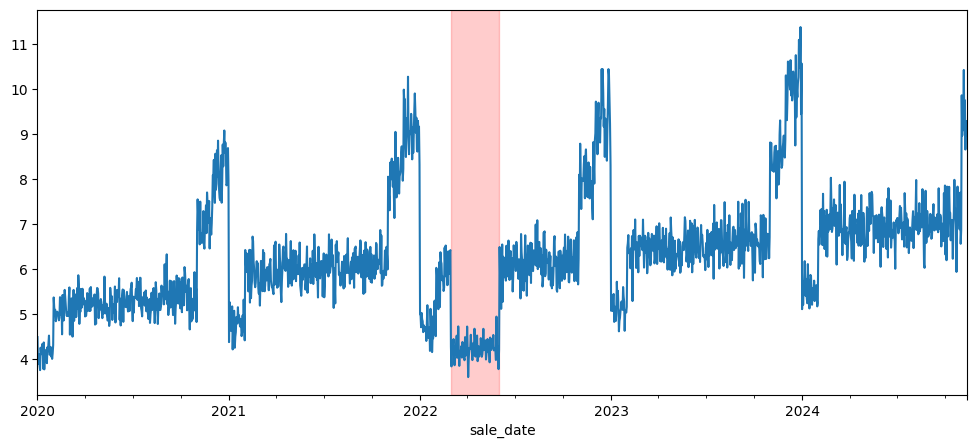

In [45]:
df.groupby('sale_date')['quantity_realistic'].mean().plot(figsize=(12,5))
plt.axvspan(pd.to_datetime('2022-03-01'),
            pd.to_datetime('2022-06-01'),
            color='red',
            alpha=0.2)
plt.show()


In [46]:
print("Mean:", df['quantity_realistic'].mean())
print("Variance:", df['quantity_realistic'].var())


Mean: 6.317707171697751
Variance: 75.87538677849575


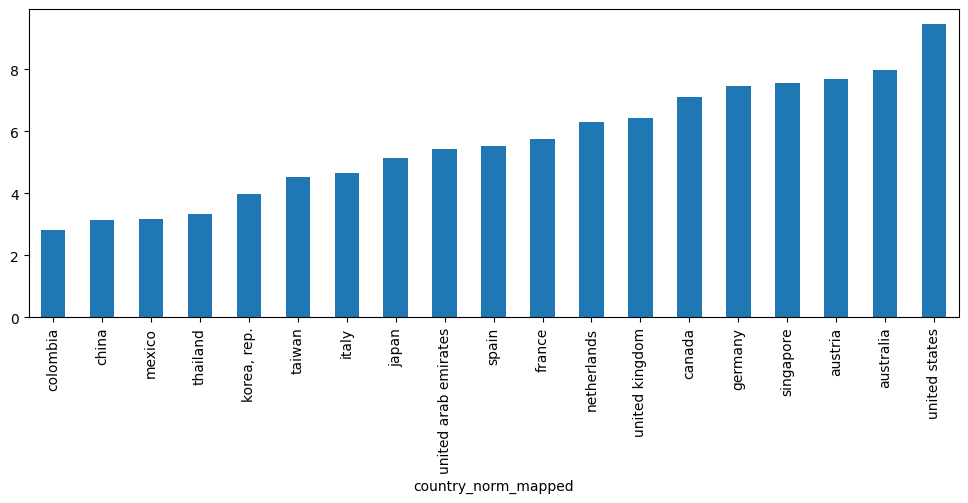

In [47]:
country_avg = df.groupby('country_norm_mapped')['quantity_realistic'].mean()

country_avg.sort_values().plot(kind='bar', figsize=(12,4))
plt.show()


In [48]:
# نزود قوة العلاقة العكسية
elasticity = -1.1  # بدل -0.8

price_change_ratio = (
    (df['price_realistic'] - df['price']) / df['price']
)

df['mu_demand'] *= (1 + elasticity * price_change_ratio)

df['mu_demand'] = df['mu_demand'].clip(lower=0.1)


In [49]:
# بدل 1.8
k = 2.8

p = k / (k + df['mu_demand'])
r = k

df['quantity_realistic'] = np.random.negative_binomial(r, p)


In [50]:
zero_mask = np.random.choice([0,1], size=len(df), p=[0.98,0.02])
df.loc[zero_mask==1, 'quantity_realistic'] = 0


In [51]:
upper_cap = df['quantity_realistic'].quantile(0.995)
df['quantity_realistic'] = df['quantity_realistic'].clip(upper=upper_cap)


In [52]:
df['sales_amount_realistic'] = (
    df['quantity_realistic'] *
    df['price_realistic']
)


In [53]:
print("Mean:", df['quantity_realistic'].mean())
print("Variance:", df['quantity_realistic'].var())
print("Max:", df['quantity_realistic'].max())


Mean: 6.245522976350702
Variance: 55.80067674598886
Max: 46


In [54]:
df_realistic = df.copy()
df_realistic.to_csv(PROC / "cleaned_apple_sales_enriched_realistic.csv", index=False)

In [ ]:
# Group by year to see the total sales for each individual year
yearly_sales = df[(df['year'] >= 2020) & (df['year'] <= 2024)].groupby('year')['sales_amount_realistic'].sum().reset_index()

print("Total Sales by Year:")
display(yearly_sales)


Total Sales by Year:


,year,sales_amount_realistic
0,2020,1.284009e+09
1,2021,1.434334e+09
2,2022,1.336405e+09
3,2023,1.539120e+09
4,2024,1.343400e+09


In [83]:
# Filter for years 2020 to 2024 and calculate the overall total sum
total_sales = df[(df['year'] >= 2020) & (df['year'] <= 2024)]['sales_amount_realistic'].sum()

print(f"Total sales from 2020 to 2024: {total_sales:,.2f}")


Total sales from 2020 to 2024: 6,937,267,929.42


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 35 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   sale_id                 1040200 non-null  object        
 1   sale_date               1040200 non-null  datetime64[ns]
 2   store_id                1040200 non-null  object        
 3   product_id              1040200 non-null  object        
 4   quantity                1040200 non-null  int64         
 5   product_name            1040200 non-null  object        
 6   launch_date             1040200 non-null  object        
 7   price                   1040200 non-null  int64         
 8   store_name              1040200 non-null  object        
 9   city                    1040200 non-null  object        
 10  category_id             1040200 non-null  object        
 11  category_name           1040200 non-null  object        
 12  sales_amount  

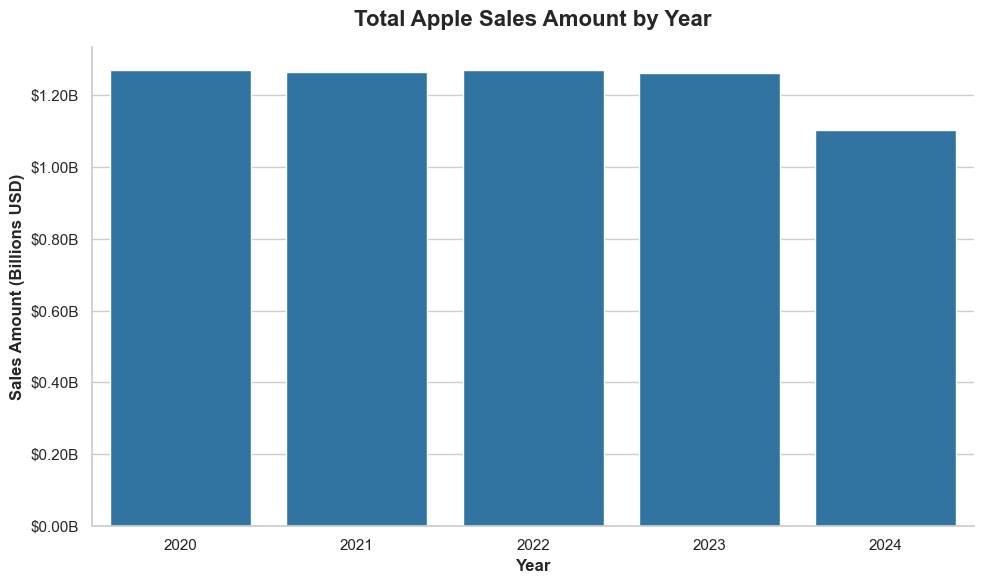

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Group the total sales by year
yearly_sales = df.groupby('year')['sales_amount'].sum().reset_index()

# 2. Set white grid styling for a cleaner, professional look
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create the Bar Plot
ax = sns.barplot(
    data=yearly_sales, 
    x='year', 
    y='sales_amount', 
    color='#1f77b4'  # Professional Apple-like clean blue
)

# 4. Format the Y-axis to drop scientific notation and display as 'Billions'
# (e.g., 1,280,000,000 becomes $1.28B)
def formatter(x, pos):
    return f'${x * 1e-9:,.2f}B'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatter))

# 5. Add titles and labels
plt.title('Total Apple Sales Amount by Year', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Sales Amount (Billions USD)', fontsize=12, fontweight='bold')

# Remove top and right borders for a modern look
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()


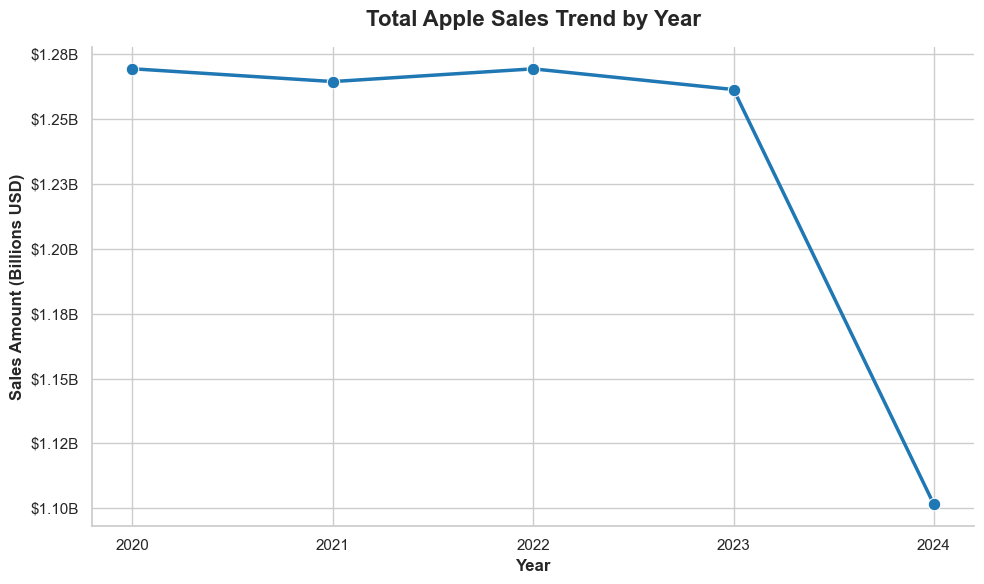

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Group the total sales by year
yearly_sales = df.groupby('year')['sales_amount'].sum().reset_index()

# 2. Set white grid styling for a cleaner, professional look
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create the Line Plot
ax = sns.lineplot(
    data=yearly_sales, 
    x='year', 
    y='sales_amount', 
    color='#1f77b4',       # Clean professional blue
    marker='o',            # Adds a dot marker on the line for each year
    markersize=9,          # Size of the dot
    linewidth=2.5          # Thicker line for better visibility
)

# 4. Format the Y-axis to show 'Billions' (e.g., $1.28B) instead of scientific notation
def formatter(x, pos):
    return f'${x * 1e-9:,.2f}B'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatter))

# 5. Force the X-axis to display only whole numbers for years
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# 6. Add titles and labels
plt.title('Total Apple Sales Trend by Year', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Sales Amount (Billions USD)', fontsize=12, fontweight='bold')

# Remove top and right borders for a modern look
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()


In [55]:
df_realistic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 35 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   sale_id                 1040200 non-null  object        
 1   sale_date               1040200 non-null  datetime64[ns]
 2   store_id                1040200 non-null  object        
 3   product_id              1040200 non-null  object        
 4   quantity                1040200 non-null  int64         
 5   product_name            1040200 non-null  object        
 6   launch_date             1040200 non-null  object        
 7   price                   1040200 non-null  int64         
 8   store_name              1040200 non-null  object        
 9   city                    1040200 non-null  object        
 10  category_id             1040200 non-null  object        
 11  category_name           1040200 non-null  object        
 12  sales_amount  

In [56]:
df['sale_date'].min()

Timestamp('2020-01-01 00:00:00')

In [57]:
df['sale_date'].max()

Timestamp('2024-11-12 00:00:00')

In [58]:
df['sale_date'].dt.to_period('M').nunique()

59

In [59]:
df.groupby(['country_norm_mapped','store_id'])['sale_date'].min()

country_norm_mapped  store_id
australia            ST-51      2020-01-01
                     ST-52      2020-01-01
                     ST-53      2020-01-01
                     ST-54      2020-01-01
                     ST-55      2020-01-01
                                   ...    
united states        ST-5       2020-01-01
                     ST-6       2020-01-01
                     ST-7       2020-01-01
                     ST-8       2020-01-01
                     ST-9       2020-01-01
Name: sale_date, Length: 75, dtype: datetime64[ns]

In [60]:
monthly = df.groupby(['year','month'])['sales_amount_realistic'].sum().reset_index()
monthly.head()

,year,month,sales_amount_realistic
0,2020,1,8.071406e+07
1,2020,2,9.375707e+07
2,2020,3,1.039779e+08
3,2020,4,9.861240e+07
4,2020,5,1.023245e+08


C:\Users\Ali Sherif\AppData\Local\Temp\ipykernel_18000\1182431257.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = store_df.groupby(pd.Grouper(key='sale_date', freq='M'))['sales_amount_realistic'].sum()


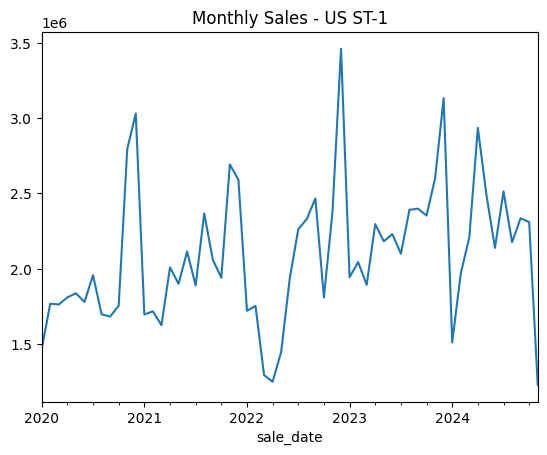

In [61]:
import matplotlib.pyplot as plt

store_df = df[(df['country_norm_mapped']=='united states') & 
              (df['store_id']=='ST-1')]

monthly = store_df.groupby(pd.Grouper(key='sale_date', freq='M'))['sales_amount_realistic'].sum()

plt.figure()
monthly.plot()
plt.title("Monthly Sales - US ST-1")
plt.show()

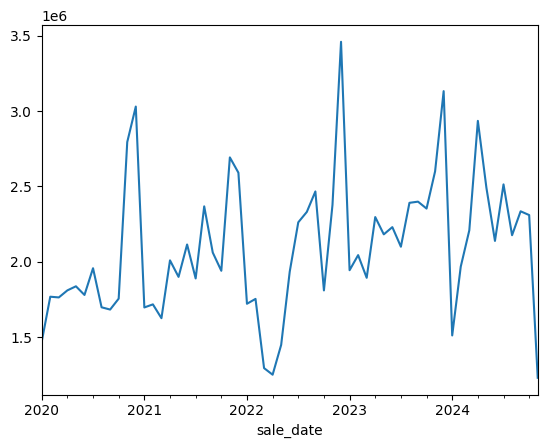

In [62]:
import matplotlib.pyplot as plt

plt.figure()
monthly.plot()
plt.show()

In [63]:
df_realistic.sample(10)

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
322319,GI-0158,2021-07-04,ST-29,P-43,5,iPhone 12 Pro,2020-01-01,1342,Apple Galeries Lafayette,Paris,...,1.0,1385.853313,550,0.000799,1.439639,0.858658,5.331954,6,8315.119881,7
496996,HP-2303,2022-04-29,ST-57,P-66,1,Mac Mini (M2),2021-10-30,874,Apple Yas Mall,Abu Dhabi,...,1.0,943.248442,849,-0.000399,0.661306,0.853664,0.341141,1,943.248442,4
724050,RM-30845,2023-05-23,ST-59,P-87,7,MagSafe Charger,2020-01-01,1744,Apple Mall of the Emirates,Dubai,...,1.0,1792.594469,1238,0.000579,1.716966,0.983243,11.543857,0,0.000000,5
201995,XT-94452,2020-12-11,ST-16,P-78,5,Magic Mouse,2020-01-01,313,Apple Regent Street,London,...,1.0,333.175953,345,0.000615,1.212044,1.166537,7.986650,8,2665.407621,12
821361,DN-53272,2023-11-05,ST-42,P-6,1,MacBook Pro 16-inch,2021-12-28,1179,Apple Orchard Road,Singapore,...,1.0,1209.337496,1404,0.000304,1.426945,0.672284,1.780292,7,8465.362470,11
561615,RZ-269448,2022-08-17,ST-9,P-77,3,Magic Keyboard with Touch ID,2020-01-01,1162,Apple Park Visitor Center,Cupertino,...,1.0,1182.665903,959,-0.000036,0.965522,0.958735,4.025959,9,10643.993129,8
4113,MV-66640,2020-01-08,ST-14,P-71,8,Apple Arcade,2020-01-01,549,Apple The Americana at Brand,Glendale,...,1.0,581.756227,7,-0.000364,0.997449,0.866628,6.689477,9,5235.806046,1
744636,UX-289497,2023-06-27,ST-52,P-1,9,MacBook,2020-01-01,1149,Apple Chadstone,Melbourne,...,1.0,1227.592545,1273,0.000328,1.417362,0.644214,9.393991,12,14731.110542,6
196821,DB-849283,2020-12-02,ST-61,P-24,3,iPad mini (6th Generation),2020-01-01,573,Apple Santa Fe,Mexico City,...,1.0,582.302621,336,0.000466,1.156715,1.086308,2.740680,2,1164.605241,12
522113,AB-601712,2022-06-10,ST-4,P-58,9,iMac 27-inch,2022-05-17,1918,Apple The Grove,Los Angeles,...,1.0,2014.171378,891,-0.000322,0.713433,1.133018,9.897014,3,6042.514133,6


In [64]:
df_realistic.describe()

,sale_date,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
count,1040200,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,...,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,2022-06-07 16:51:18.598730752,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04,...,1.040002e+00,1.096057e+03,8.887023e+02,1.674567e-04,1.138149e+00,9.951873e-01,6.437436e+00,6.245523e+00,6.669167e+03,6.375341e+00
min,2020-01-01 00:00:00,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03,...,1.000000e+00,1.788246e+02,0.000000e+00,-4.962412e-04,5.000000e-01,6.442142e-01,1.124592e-01,0.000000e+00,0.000000e+00,1.000000e+00
25%,2021-03-20 00:00:00,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04,...,1.000000e+00,6.294309e+02,4.440000e+02,-1.429487e-04,9.299385e-01,8.603374e-01,2.482844e+00,1.000000e+00,1.221419e+03,3.000000e+00
50%,2022-06-07 00:00:00,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04,...,1.000000e+00,1.128185e+03,8.880000e+02,1.951382e-04,1.074579e+00,9.869100e-01,4.896092e+00,4.000000e+00,3.556643e+03,6.000000e+00
75%,2023-08-27 00:00:00,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04,...,1.000000e+00,1.492781e+03,1.334000e+03,4.945074e-04,1.372622e+00,1.133018e+00,8.671425e+00,8.000000e+00,8.465278e+03,9.000000e+00
max,2024-11-12 00:00:00,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04,...,1.400000e+00,2.427058e+03,1.777000e+03,7.993439e-04,1.800000e+00,1.469524e+00,9.504407e+01,4.600000e+01,1.025249e+05,1.200000e+01
std,NaN,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04,...,1.200021e-01,5.123379e+02,5.132911e+02,3.862175e-04,3.569842e-01,1.715577e-01,5.614559e+00,7.469985e+00,9.152623e+03,3.387588e+00


In [65]:
df_realistic.isnull().sum()

sale_id                   0
sale_date                 0
store_id                  0
product_id                0
quantity                  0
product_name              0
launch_date               0
price                     0
store_name                0
city                      0
category_id               0
category_name             0
sales_amount              0
invalid_launch_flag       0
product_age_days          0
exchange_rate             0
inflation_rate            0
internet_usage_pct        0
country_norm_mapped       0
year                      0
gdp_type                  0
gdp_per_capita            0
season_factor             0
economic_factor           0
promo_flag                0
promo_factor              0
price_realistic           0
days_from_start           0
product_trend             0
trend_factor              0
store_factor              0
mu_demand                 0
quantity_realistic        0
sales_amount_realistic    0
month                     0
dtype: int64

In [66]:
df_realistic.sample(50)

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
274885,UB-0768,2021-04-14,ST-68,P-81,7,Apple Pencil (2nd Generation),2020-01-01,1506,Apple Champs-Elysees,Paris,...,1.0,1437.711991,469,0.000208,1.097723,1.163143,8.934768,13,18690.255884,4
404686,BV-3691,2021-11-23,ST-8,P-4,7,MacBook Pro 13-inch,2021-01-17,1351,Apple Pioneer Place,Portland,...,1.0,1378.384632,692,-0.000143,0.901079,0.809810,9.273382,6,8270.307789,11
714085,UA-769089,2023-05-05,ST-49,P-81,3,Apple Pencil (2nd Generation),2020-01-01,1506,Apple Yorkdale,Toronto,...,1.0,1493.397383,1220,0.000208,1.254205,0.796929,3.392136,5,7466.986914,5
730372,PG-2439,2023-06-02,ST-40,P-75,7,HomePod mini,2020-01-02,266,Apple Causeway Bay,Hong Kong,...,1.0,275.414973,1248,0.000591,1.737677,0.860337,4.886345,6,1652.489837,6
7771,CR-834856,2020-01-14,ST-48,P-74,8,HomePod,2020-01-01,1202,Apple Sainte-Catherine,Montreal,...,1.0,1209.603210,13,-0.000363,0.995277,1.087753,6.322181,9,10886.428886,1
380440,RS-83929,2021-10-12,ST-51,P-77,5,Magic Keyboard with Touch ID,2020-01-01,1162,Apple Sydney,Sydney,...,1.0,1166.529123,650,-0.000036,0.976631,1.203033,7.334510,6,6999.174739,10
1028245,SX-74632,2024-10-23,ST-32,P-8,6,MacBook Air (Retina),2020-01-16,1847,Apple Omotesando,Tokyo,...,1.4,1578.369838,1757,-0.000203,0.643756,1.250931,5.911481,16,25253.917401,10
853514,DE-88726,2023-12-30,ST-37,P-46,10,Apple Watch Ultra,2020-01-01,346,Apple Sanlitun,Beijing,...,1.0,370.696628,1459,0.000195,1.284707,0.935741,7.833823,4,1482.786510,12
421829,BH-00067,2021-12-22,ST-27,P-52,2,Apple Watch Series 6,2020-01-01,462,Apple Rosenstrasse,Munich,...,1.0,492.421458,721,0.000509,1.367110,1.120681,4.371655,5,2462.107288,12
166779,XM-71946,2020-10-11,ST-50,P-16,10,Beats Studio Buds,2020-01-01,762,Apple Metrotown,Burnaby,...,1.0,762.383387,284,0.000208,1.059104,1.026704,10.032670,6,4574.300322,10


In [67]:
df_realistic['quantity_realistic'].value_counts()

quantity_realistic
0     147202
1     134388
2     116529
3      97571
4      81351
5      67203
6      56017
7      46914
8      39661
9      33128
10     28351
11     24121
12     20724
13     17752
14     15242
15     13284
16     11555
17     10088
18      8785
19      7491
20      6647
21      5861
46      5363
22      5298
23      4634
24      4029
25      3524
26      3113
27      2872
28      2540
29      2375
30      1964
31      1736
32      1662
33      1492
34      1317
35      1252
36      1077
37       970
38       885
39       767
40       722
41       672
42       627
43       541
44       466
45       437
Name: count, dtype: int64

In [68]:
df_realistic.describe()

,sale_date,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
count,1040200,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,...,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,2022-06-07 16:51:18.598730752,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04,...,1.040002e+00,1.096057e+03,8.887023e+02,1.674567e-04,1.138149e+00,9.951873e-01,6.437436e+00,6.245523e+00,6.669167e+03,6.375341e+00
min,2020-01-01 00:00:00,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03,...,1.000000e+00,1.788246e+02,0.000000e+00,-4.962412e-04,5.000000e-01,6.442142e-01,1.124592e-01,0.000000e+00,0.000000e+00,1.000000e+00
25%,2021-03-20 00:00:00,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04,...,1.000000e+00,6.294309e+02,4.440000e+02,-1.429487e-04,9.299385e-01,8.603374e-01,2.482844e+00,1.000000e+00,1.221419e+03,3.000000e+00
50%,2022-06-07 00:00:00,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04,...,1.000000e+00,1.128185e+03,8.880000e+02,1.951382e-04,1.074579e+00,9.869100e-01,4.896092e+00,4.000000e+00,3.556643e+03,6.000000e+00
75%,2023-08-27 00:00:00,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04,...,1.000000e+00,1.492781e+03,1.334000e+03,4.945074e-04,1.372622e+00,1.133018e+00,8.671425e+00,8.000000e+00,8.465278e+03,9.000000e+00
max,2024-11-12 00:00:00,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04,...,1.400000e+00,2.427058e+03,1.777000e+03,7.993439e-04,1.800000e+00,1.469524e+00,9.504407e+01,4.600000e+01,1.025249e+05,1.200000e+01
std,NaN,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04,...,1.200021e-01,5.123379e+02,5.132911e+02,3.862175e-04,3.569842e-01,1.715577e-01,5.614559e+00,7.469985e+00,9.152623e+03,3.387588e+00


In [69]:
zero_count = (df['quantity_realistic'] == 0).sum()
total = len(df)

print("Zero count:", zero_count)
print("Zero percentage:", zero_count / total * 100)


Zero count: 147202
Zero percentage: 14.151317054412612


In [86]:
# Filter the dataframe for the year 2024 
# AND where either sales_amount is 0 OR quantity is 0
zero_sales_2024 = df[
    (df['year'] == 2024) & 
    ((df['sales_amount'] == 0) | (df['quantity'] == 0))
]

# Get the number of rows matching that condition
num_zero_rows = len(zero_sales_2024)

print(f"Number of rows in 2024 with 0 sales or 0 quantity: {num_zero_rows}")

# If you want to see a preview of those exact rows, you can run:
# display(zero_sales_2024.head())


Number of rows in 2024 with 0 sales or 0 quantity: 0


In [70]:
df_daily = df.groupby(
    ['sale_date','store_id','product_id']
).agg({
    'quantity_realistic':'sum',
    'price_realistic':'mean'
}).reset_index()


In [71]:
df_daily.shape

(995690, 5)

In [72]:
df_realistic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 35 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   sale_id                 1040200 non-null  object        
 1   sale_date               1040200 non-null  datetime64[ns]
 2   store_id                1040200 non-null  object        
 3   product_id              1040200 non-null  object        
 4   quantity                1040200 non-null  int64         
 5   product_name            1040200 non-null  object        
 6   launch_date             1040200 non-null  object        
 7   price                   1040200 non-null  int64         
 8   store_name              1040200 non-null  object        
 9   city                    1040200 non-null  object        
 10  category_id             1040200 non-null  object        
 11  category_name           1040200 non-null  object        
 12  sales_amount  

In [73]:
# أولًا نحسب revenue لو مش موجود
df_realistic['revenue_temp'] = (
    df_realistic['price_realistic'] *
    df_realistic['quantity_realistic']
)

# نعمل aggregation vectorized
df_daily = (
    df_realistic
    .groupby(['sale_date', 'store_id', 'product_id'], as_index=False)
    .agg({
        'quantity_realistic': 'sum',
        'revenue_temp': 'sum',
        'product_name': 'first',
        'category_id': 'first',
        'category_name': 'first',
        'store_name': 'first',
        'city': 'first',
        'country_norm_mapped': 'first',
        'exchange_rate': 'mean',
        'inflation_rate': 'mean',
        'gdp_per_capita': 'mean',
        'internet_usage_pct': 'mean',
        'promo_flag': 'max',
        'year': 'first',
        'month': 'first'
    })
)

# نحسب weighted price بسرعة
df_daily['price_realistic'] = (
    df_daily['revenue_temp'] /
    df_daily['quantity_realistic']
)

# نشيل العمود المؤقت
df_daily.drop(columns=['revenue_temp'], inplace=True)
df_daily.shape
df_daily.info()
df_daily.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995690 entries, 0 to 995689
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   sale_date            995690 non-null  datetime64[ns]
 1   store_id             995690 non-null  object        
 2   product_id           995690 non-null  object        
 3   quantity_realistic   995690 non-null  int32         
 4   product_name         995690 non-null  object        
 5   category_id          995690 non-null  object        
 6   category_name        995690 non-null  object        
 7   store_name           995690 non-null  object        
 8   city                 995690 non-null  object        
 9   country_norm_mapped  995690 non-null  object        
 10  exchange_rate        995690 non-null  float64       
 11  inflation_rate       995690 non-null  float64       
 12  gdp_per_capita       995690 non-null  float64       
 13  internet_usage

,sale_date,quantity_realistic,exchange_rate,inflation_rate,gdp_per_capita,internet_usage_pct,promo_flag,year,month,price_realistic
count,995690,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,859824.000000
mean,2022-06-07 17:28:07.370968320,6.524715,154.226893,3.248501,46809.095354,89.995375,0.104016,2021.945840,6.376155,1092.143399
min,2020-01-01 00:00:00,0.000000,0.727065,-2.079403,5339.687114,69.795300,0.000000,2020.000000,1.000000,178.824608
25%,2021-03-20 00:00:00,1.000000,1.000000,1.233584,33509.012800,86.981500,0.000000,2021.000000,3.000000,623.979499
50%,2022-06-07 00:00:00,4.000000,1.349909,2.863910,49040.694750,92.000000,0.000000,2022.000000,6.000000,1121.795136
75%,2023-08-26 00:00:00,9.000000,7.083998,4.878357,64407.484260,94.818200,0.000000,2023.000000,9.000000,1491.374597
max,2024-11-12 00:00:00,112.000000,4325.955000,11.735904,90674.066630,100.000000,1.000000,2024.000000,12.000000,2427.058417
std,NaN,7.811987,669.900097,2.625305,23617.950903,7.552562,0.305282,1.393707,3.387909,513.016319


In [74]:
df_daily.shape

(995690, 18)

In [75]:
df_daily.info()
df_daily.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995690 entries, 0 to 995689
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   sale_date            995690 non-null  datetime64[ns]
 1   store_id             995690 non-null  object        
 2   product_id           995690 non-null  object        
 3   quantity_realistic   995690 non-null  int32         
 4   product_name         995690 non-null  object        
 5   category_id          995690 non-null  object        
 6   category_name        995690 non-null  object        
 7   store_name           995690 non-null  object        
 8   city                 995690 non-null  object        
 9   country_norm_mapped  995690 non-null  object        
 10  exchange_rate        995690 non-null  float64       
 11  inflation_rate       995690 non-null  float64       
 12  gdp_per_capita       995690 non-null  float64       
 13  internet_usage

,sale_date,quantity_realistic,exchange_rate,inflation_rate,gdp_per_capita,internet_usage_pct,promo_flag,year,month,price_realistic
count,995690,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,859824.000000
mean,2022-06-07 17:28:07.370968320,6.524715,154.226893,3.248501,46809.095354,89.995375,0.104016,2021.945840,6.376155,1092.143399
min,2020-01-01 00:00:00,0.000000,0.727065,-2.079403,5339.687114,69.795300,0.000000,2020.000000,1.000000,178.824608
25%,2021-03-20 00:00:00,1.000000,1.000000,1.233584,33509.012800,86.981500,0.000000,2021.000000,3.000000,623.979499
50%,2022-06-07 00:00:00,4.000000,1.349909,2.863910,49040.694750,92.000000,0.000000,2022.000000,6.000000,1121.795136
75%,2023-08-26 00:00:00,9.000000,7.083998,4.878357,64407.484260,94.818200,0.000000,2023.000000,9.000000,1491.374597
max,2024-11-12 00:00:00,112.000000,4325.955000,11.735904,90674.066630,100.000000,1.000000,2024.000000,12.000000,2427.058417
std,NaN,7.811987,669.900097,2.625305,23617.950903,7.552562,0.305282,1.393707,3.387909,513.016319


In [76]:
# رتب الداتا الأول
df_daily = df_daily.sort_values(
    ['store_id', 'product_id', 'sale_date']
)

# Fill forward لكل store × product
df_daily['price_realistic'] = (
    df_daily
    .groupby(['store_id', 'product_id'])['price_realistic']
    .ffill()
)

# لو أول يوم كان NaN (مفيش سعر قبله)
df_daily['price_realistic'] = (
    df_daily
    .groupby(['store_id', 'product_id'])['price_realistic']
    .bfill()
)


In [77]:
df_daily.info()
df_daily.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 995690 entries, 14991 to 995689
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   sale_date            995690 non-null  datetime64[ns]
 1   store_id             995690 non-null  object        
 2   product_id           995690 non-null  object        
 3   quantity_realistic   995690 non-null  int32         
 4   product_name         995690 non-null  object        
 5   category_id          995690 non-null  object        
 6   category_name        995690 non-null  object        
 7   store_name           995690 non-null  object        
 8   city                 995690 non-null  object        
 9   country_norm_mapped  995690 non-null  object        
 10  exchange_rate        995690 non-null  float64       
 11  inflation_rate       995690 non-null  float64       
 12  gdp_per_capita       995690 non-null  float64       
 13  internet_usage_

,sale_date,quantity_realistic,exchange_rate,inflation_rate,gdp_per_capita,internet_usage_pct,promo_flag,year,month,price_realistic
count,995690,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000
mean,2022-06-07 17:28:07.370968832,6.524715,154.226893,3.248501,46809.095354,89.995375,0.104016,2021.945840,6.376155,1094.492252
min,2020-01-01 00:00:00,0.000000,0.727065,-2.079403,5339.687114,69.795300,0.000000,2020.000000,1.000000,178.824608
25%,2021-03-20 00:00:00,1.000000,1.000000,1.233584,33509.012800,86.981500,0.000000,2021.000000,3.000000,628.379535
50%,2022-06-07 00:00:00,4.000000,1.349909,2.863910,49040.694750,92.000000,0.000000,2022.000000,6.000000,1126.062471
75%,2023-08-26 00:00:00,9.000000,7.083998,4.878357,64407.484260,94.818200,0.000000,2023.000000,9.000000,1490.538532
max,2024-11-12 00:00:00,112.000000,4325.955000,11.735904,90674.066630,100.000000,1.000000,2024.000000,12.000000,2427.058417
std,NaN,7.811987,669.900097,2.625305,23617.950903,7.552562,0.305282,1.393707,3.387909,511.618537


In [78]:
df_daily.to_csv(PROC / "cleaned_apple_sales_daily.csv", index=False)

In [79]:
import pandas as pd
import numpy as np

# تأكد إن التاريخ datetime
df['sale_date'] = pd.to_datetime(df['sale_date'])

# =========================
# 1️⃣ Monthly Aggregation
# =========================
monthly = (
    df
    .groupby([
        'country_norm_mapped',
        'store_id',
        pd.Grouper(key='sale_date', freq='ME')
    ])['sales_amount_realistic']
    .sum()
    .reset_index()
)

monthly = monthly.sort_values(['country_norm_mapped','store_id','sale_date'])

# =========================
# 2️⃣ Lag Features
# =========================
lags = [1,2,3,6,12]

for lag in lags:
    monthly[f'lag_{lag}'] = (
        monthly
        .groupby(['country_norm_mapped','store_id'])['sales_amount_realistic']
        .shift(lag)
    )

# =========================
# 3️⃣ Rolling Features
# =========================
monthly['rolling_mean_3'] = (
    monthly
    .groupby(['country_norm_mapped','store_id'])['sales_amount_realistic']
    .shift(1)
    .rolling(3)
    .mean()
)

monthly['rolling_std_6'] = (
    monthly
    .groupby(['country_norm_mapped','store_id'])['sales_amount_realistic']
    .shift(1)
    .rolling(6)
    .std()
)

# =========================
# 4️⃣ Time Features
# =========================
monthly['month'] = monthly['sale_date'].dt.month
monthly['year'] = monthly['sale_date'].dt.year
monthly['quarter'] = monthly['sale_date'].dt.quarter

monthly['month_sin'] = np.sin(2 * np.pi * monthly['month'] / 12)
monthly['month_cos'] = np.cos(2 * np.pi * monthly['month'] / 12)

# =========================
# 5️⃣ Log Transform (اختياري لكن مفضل)
# =========================
monthly['target_log'] = np.log1p(monthly['sales_amount_realistic'])

# =========================
# 6️⃣ Drop NaNs
# =========================
monthly = monthly.dropna().reset_index(drop=True)

monthly.head()

,country_norm_mapped,store_id,sale_date,sales_amount_realistic,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_6,month,year,quarter,month_sin,month_cos,target_log
0,australia,ST-51,2021-01-31,2.009279e+06,2.733613e+06,2.802823e+06,2.002390e+06,1.967326e+06,1.548129e+06,2.512942e+06,438315.846333,1,2021,1,0.500000,8.660254e-01,14.513287
1,australia,ST-51,2021-02-28,2.290813e+06,2.009279e+06,2.733613e+06,2.802823e+06,1.905526e+06,1.325129e+06,2.515238e+06,434025.238046,2,2021,1,0.866025,5.000000e-01,14.644418
2,australia,ST-51,2021-03-31,2.241242e+06,2.290813e+06,2.009279e+06,2.733613e+06,1.835399e+06,1.830223e+06,2.344568e+06,406754.669711,3,2021,1,1.000000,6.123234e-17,14.622541
3,australia,ST-51,2021-04-30,2.297937e+06,2.241242e+06,2.290813e+06,2.009279e+06,2.002390e+06,1.773240e+06,2.180445e+06,347676.891900,4,2021,2,0.866025,-5.000000e-01,14.647523
4,australia,ST-51,2021-05-31,2.581544e+06,2.297937e+06,2.241242e+06,2.290813e+06,2.802823e+06,1.820352e+06,2.276664e+06,307789.110411,5,2021,2,0.500000,-8.660254e-01,14.763899


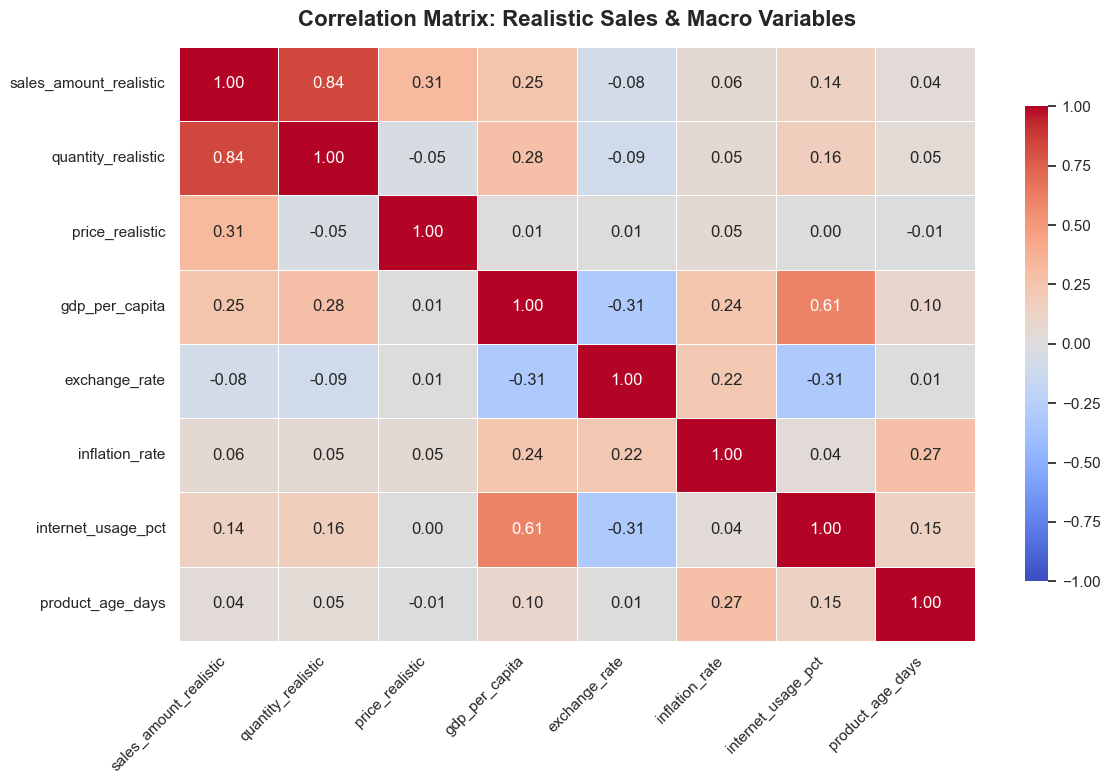

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the specific numerical columns we want to compare
cols_to_correlate = [
    'sales_amount_realistic',
    'quantity_realistic', 
    'price_realistic',
    'gdp_per_capita',
    'exchange_rate',
    'inflation_rate',
    'internet_usage_pct',
    'product_age_days'
]

# 2. Calculate the correlation matrix
corr_matrix = df[cols_to_correlate].corr()

# 3. Set up the plot size and style
plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

# 4. Generate the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,               # Display the actual correlation numbers
    fmt=".2f",                # Round numbers to 2 decimal places
    cmap="coolwarm",          # Blue = Negative correlation, Red = Positive
    vmin=-1, vmax=1,          # Lock the scale between -1 and 1
    linewidths=0.5,           # Add subtle lines between squares
    cbar_kws={"shrink": .8}   # Shrink color bar slightly for aesthetics
)

# 5. Add titles and fix angles for readability
plt.title('Correlation Matrix: Realistic Sales & Macro Variables', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()


In [89]:
import pandas as pd

# 1. Grab just the product and category columns, remove duplicates, and sort them
product_list = (
    df[['product_name', 'category_name']]
    .drop_duplicates()
    .sort_values(by=['category_name', 'product_name'])
    .reset_index(drop=True)
)

# 2. Tell pandas to show ALL rows (otherwise it summarizes with "...")
pd.set_option('display.max_rows', None)

# 3. Display the final clean table
display(product_list)


,product_name,category_name
0,AirTag,Accessories
1,Apple Pencil (1st Generation),Accessories
2,Apple Pencil (2nd Generation),Accessories
3,Leather Case for iPhone,Accessories
4,Lightning to USB Cable,Accessories
5,MagSafe Battery Pack,Accessories
6,MagSafe Charger,Accessories
7,Magic Keyboard,Accessories
8,Magic Keyboard with Touch ID,Accessories
9,Magic Mouse,Accessories


In [90]:
# Same drop_duplicates logic as above
product_list = df[['product_name', 'category_name']].drop_duplicates().sort_values('category_name')

# Print out grouped by category
current_category = ""
for idx, row in product_list.iterrows():
    if row['category_name'] != current_category:
        current_category = row['category_name']
        print(f"\n[{current_category.upper()}]")
    print(f"  - {row['product_name']}")



[ACCESSORIES]
  - Leather Case for iPhone
  - Magic Keyboard with Touch ID
  - Apple Pencil (2nd Generation)
  - Lightning to USB Cable
  - Smart Keyboard Folio
  - Smart Cover for iPad
  - Silicone Case for iPhone
  - AirTag
  - MagSafe Battery Pack
  - Magic Trackpad
  - MagSafe Charger
  - Magic Keyboard
  - Apple Pencil (1st Generation)
  - Magic Mouse

[AUDIO]
  - AirPods (2nd Generation)
  - HomePod (2nd Generation)
  - AirPods Pro
  - Beats Powerbeats Pro
  - AirPods Max
  - AirPods (3rd Generation)
  - AirPods Pro (2nd Generation)
  - Beats Solo Pro
  - Beats Studio Buds
  - HomePod mini
  - Beats Fit Pro

[DESKTOP]
  - Mac Pro (2023)
  - Mac Pro (Tower)
  - iMac with Retina Display
  - Mac Mini (M2)
  - iMac Pro
  - Mac Studio
  - iMac 27-inch
  - Mac Mini
  - iMac 24-inch
  - Mac Pro (Rack)

[LAPTOP]
  - MacBook Air (M1)
  - MacBook Air (Retina)
  - MacBook (Retina)
  - MacBook Pro 16-inch
  - MacBook Pro 14-inch
  - MacBook
  - MacBook Pro 13-inch
  - MacBook Pro (Touch Bar

In [91]:
import pandas as pd

# 1. Grab the country, year, and GDP columns, remove duplicates, and sort them
gdp_list = (
    df[['country_norm_mapped', 'year', 'gdp_per_capita']]
    .drop_duplicates()
    .sort_values(by=['country_norm_mapped', 'year'])
    .reset_index(drop=True)
)

# 2. Tell pandas to show ALL rows (so nothing gets cut off)
pd.set_option('display.max_rows', None)

# 3. Display the final clean table
display(gdp_list)


,country_norm_mapped,year,gdp_per_capita
0,australia,2020,51791.540180
1,australia,2021,60607.778860
2,australia,2022,64997.013650
3,australia,2023,64835.919980
4,australia,2024,64407.484260
5,austria,2020,48716.409890
6,austria,2021,53648.719070
7,austria,2022,52176.664910
8,austria,2023,56033.573790
9,austria,2024,56833.196050


In [92]:
# Extract the unique values and sort 
gdp_list_text = (
    df[['country_norm_mapped', 'year', 'gdp_per_capita']]
    .drop_duplicates()
    .sort_values(by=['country_norm_mapped', 'year'])
)

# Loop through and print out grouped by country
current_country = ""
for idx, row in gdp_list_text.iterrows():
    # Print the Country as a header when it changes
    if row['country_norm_mapped'] != current_country:
        current_country = row['country_norm_mapped']
        print(f"\n[{current_country.upper()}]")
        
    # Print the Year and format the GDP as currency
    print(f"  - {row['year']}: ${row['gdp_per_capita']:,.2f}")



[AUSTRALIA]
  - 2020: $51,791.54
  - 2021: $60,607.78
  - 2022: $64,997.01
  - 2023: $64,835.92
  - 2024: $64,407.48

[AUSTRIA]
  - 2020: $48,716.41
  - 2021: $53,648.72
  - 2022: $52,176.66
  - 2023: $56,033.57
  - 2024: $56,833.20

[CANADA]
  - 2020: $43,537.84
  - 2021: $52,886.66
  - 2022: $56,256.80
  - 2023: $54,220.33
  - 2024: $54,282.62

[CHINA]
  - 2020: $10,627.46
  - 2021: $12,887.44
  - 2022: $12,970.61
  - 2023: $12,951.18
  - 2024: $13,303.15

[COLOMBIA]
  - 2020: $5,339.69
  - 2021: $6,222.62
  - 2022: $6,680.45
  - 2023: $7,000.84
  - 2024: $7,913.99

[FRANCE]
  - 2020: $39,169.86
  - 2021: $43,725.10
  - 2022: $41,082.81
  - 2023: $44,690.93
  - 2024: $46,150.49

[GERMANY]
  - 2020: $47,379.77
  - 2021: $52,265.65
  - 2022: $49,686.12
  - 2023: $53,940.41
  - 2024: $55,800.22

[ITALY]
  - 2020: $32,091.49
  - 2021: $36,852.54
  - 2022: $35,653.90
  - 2023: $39,065.42
  - 2024: $40,226.05

[JAPAN]
  - 2020: $40,028.73
  - 2021: $40,094.56
  - 2022: $34,065.64
  - 2023

In [93]:
df_country = df.groupby('country_norm_mapped').agg({
    'sales_amount_realistic': 'sum',
    'gdp_per_capita': 'mean',
    'exchange_rate': 'mean',
    'inflation_rate': 'mean'
}).reset_index()

In [95]:
df_country.corr(numeric_only=True)

,sales_amount_realistic,gdp_per_capita,exchange_rate,inflation_rate
sales_amount_realistic,1.000000,0.524849,-0.188081,0.033496
gdp_per_capita,0.524849,1.000000,-0.410161,0.038022
exchange_rate,-0.188081,-0.410161,1.000000,0.522871
inflation_rate,0.033496,0.038022,0.522871,1.000000


In [96]:
# Groups all data by the exact 'price', and lists all unique exchange rates bound to that price
price_exchange_grouping = df.groupby('price')['exchange_rate'].unique().reset_index()

display(price_exchange_grouping)


,price,exchange_rate
0,231,"[1.0, 3.6725, 1.341152672, 1180.265833, 106.77..."
1,253,"[1.453085118, 0.875506397, 1.0, 3693.275833, 1..."
2,266,"[1.341152672, 106.7745823, 1.0, 0.875506397, 2..."
3,308,"[1.379741667, 1180.265833, 31.29367321, 106.77..."
4,313,"[1.0, 6.900767269, 31.29367321, 0.875506397, 0..."
5,343,"[21.48560833, 0.875506397, 6.900767269, 1.0, 3..."
6,346,"[6.900767269, 3.6725, 0.875506397, 1180.265833..."
7,368,"[31.29367321, 21.48560833, 3.6725, 1.341152672..."
8,404,"[1.0, 21.48560833, 106.7745823, 0.875506397, 1..."
9,438,"[1.0, 1.379741667, 106.7745823, 0.875506397, 1..."


In [97]:
df.sample(50)

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
294486,WJ-700486,2021-05-18,ST-40,P-60,3,iMac with Retina Display,2020-07-24,343,Apple Causeway Bay,Hong Kong,...,1.0,325.870008,503,0.000322,1.161947,0.860337,1.645077,5,1629.350040,5
148566,HN-9299,2020-09-10,ST-27,P-52,3,Apple Watch Series 6,2020-01-01,462,Apple Rosenstrasse,Munich,...,1.0,465.890548,253,0.000509,1.128819,1.120681,3.775025,7,3261.233837,9
162091,IO-215070,2020-10-04,ST-49,P-9,7,MacBook Pro (Touch Bar),2020-01-01,1304,Apple Yorkdale,Toronto,...,1.0,1328.042865,277,-0.000011,0.996947,0.796929,4.957757,2,2656.085730,10
975783,RD-832491,2024-07-26,ST-73,P-10,2,MacBook (Early 2015),2022-11-19,741,Apple Covent Garden,London,...,1.0,747.660089,1668,-0.000283,0.528618,1.196278,1.352397,4,2990.640355,7
182393,QT-4025,2020-11-07,ST-71,P-47,2,Apple Watch SE,2020-01-20,1546,Apple Yeouido,Seoul,...,1.0,1521.808618,311,0.000217,1.067621,0.873177,1.682770,0,0.000000,11
5148,EF-0235,2020-01-09,ST-32,P-27,1,iPad Air (4th Generation),2020-01-01,952,Apple Omotesando,Tokyo,...,1.0,963.624520,8,0.000496,1.003966,1.250931,0.839639,1,963.624520,1
794868,DW-188413,2023-09-21,ST-45,P-75,8,HomePod mini,2023-06-22,266,Apple Jewel Changi Airport,Singapore,...,1.4,234.107387,1359,0.000591,1.800000,0.867157,32.528245,31,7257.328988,9
138504,BY-916518,2020-08-24,ST-67,P-58,10,iMac 27-inch,2020-01-01,1918,Apple Chadstone,Melbourne,...,1.4,1652.015549,236,-0.000322,0.924097,0.838652,15.242228,3,4956.046646,8
483985,JP-126398,2022-04-06,ST-67,P-79,10,Magic Trackpad,2020-01-01,1242,Apple Chadstone,Melbourne,...,1.0,1304.685397,826,-0.000410,0.661135,0.838652,4.562868,6,7828.112380,4
662277,XC-29590,2023-02-06,ST-49,P-38,7,iPhone 13 Pro,2021-03-22,308,Apple Yorkdale,Toronto,...,1.0,317.218592,1132,0.000183,1.207634,0.796929,7.080682,4,1268.874368,2


=== iPhone 13 Pro Pricing Data by Year ===


,year,price,price_realistic,change_ratio_pct,yoy_growth_pct
0,2020,308.0,305.83,-0.71,NaN
1,2021,308.0,310.97,0.96,1.68
2,2022,308.0,321.14,4.27,3.27
3,2023,308.0,316.67,2.82,-1.39
4,2024,308.0,310.61,0.85,-1.91


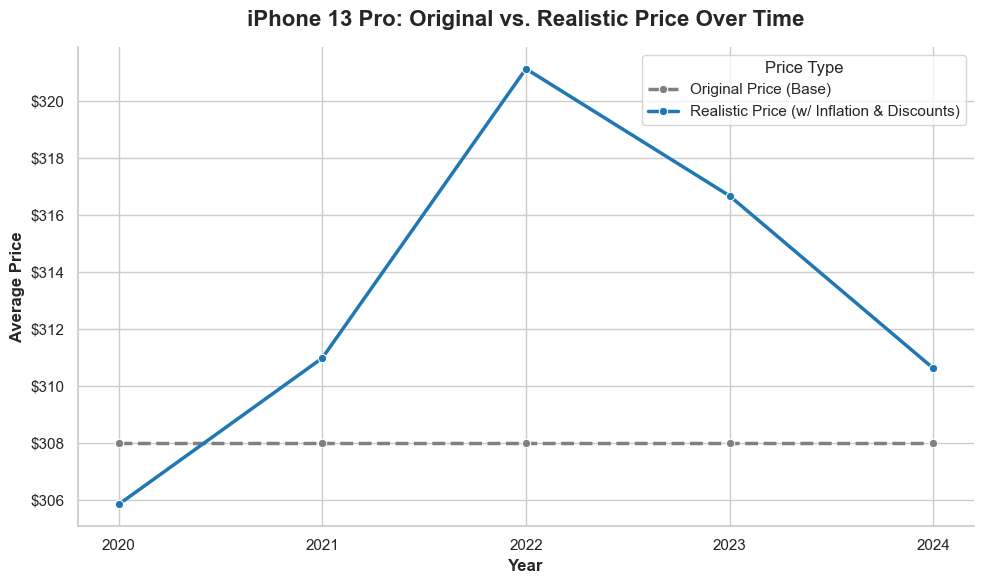

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Filter the dataset for exactly 'iPhone 13 Pro'
# (If there are 0 rows returned, double check the exact spelling of the product name)
iphone_df = df[df['product_name'] == 'iPhone 13 Pro'].copy()

# 2. Group by Year and calculate the average price and average realistic price
yearly_prices = (
    iphone_df
    .groupby('year')[['price', 'price_realistic']]
    .mean()
    .reset_index()
)

# 3. Calculate Metrics to answer your questions
# A: Difference between Realistic and Base Price
yearly_prices['change_ratio_pct'] = ((yearly_prices['price_realistic'] - yearly_prices['price']) / yearly_prices['price']) * 100

# B: Year-Over-Year (YoY) Growth: Did the Realistic Price get more expensive than the previous year?
yearly_prices['yoy_growth_pct'] = yearly_prices['price_realistic'].pct_change() * 100

# Print the clean table
print("=== iPhone 13 Pro Pricing Data by Year ===")
display(yearly_prices.round(2))

# 4. Visualize the Comparison
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plot Original Base Price (Usually a flat line)
sns.lineplot(
    data=yearly_prices, 
    x='year', 
    y='price', 
    marker='o', 
    label='Original Price (Base)', 
    linewidth=2.5, 
    color='gray',
    linestyle='--'
)

# Plot Realistic Price (Should trend up with inflation)
sns.lineplot(
    data=yearly_prices, 
    x='year', 
    y='price_realistic', 
    marker='o', 
    label='Realistic Price (w/ Inflation & Discounts)', 
    linewidth=2.5, 
    color='#1f77b4'
)

# Formatting
plt.title('iPhone 13 Pro: Original vs. Realistic Price Over Time', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Average Price', fontsize=12, fontweight='bold')

# Ensure X-axis only uses whole years (e.g. 2021) and Y axis formats as Cash ($)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))

plt.legend(title='Price Type', fontsize=11)
sns.despine()

plt.tight_layout()
plt.show()


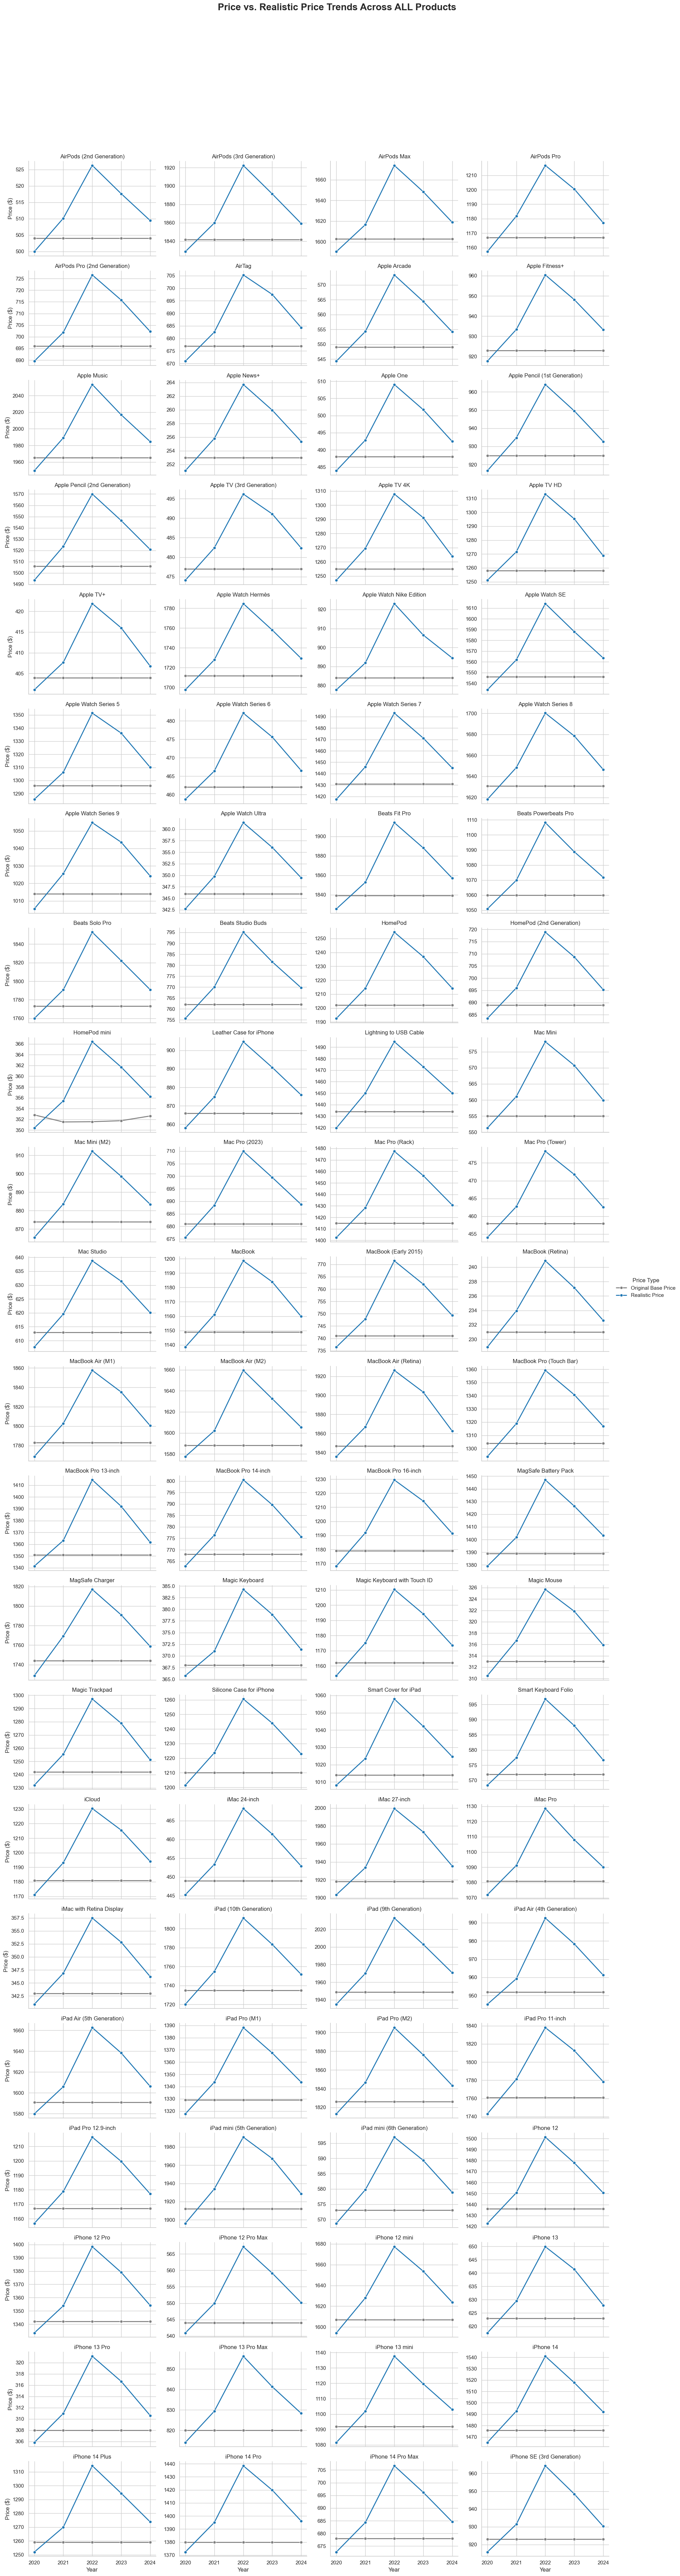

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Group the entire dataset by both Product Name AND Year
yearly_product_prices = (
    df.groupby(['product_name', 'year'])[['price', 'price_realistic']]
    .mean()
    .reset_index()
)

# 2. "Melt" the dataframe. (This perfectly stacks the two price columns so Seaborn can easily plot them using 'hue')
melted_prices = yearly_product_prices.melt(
    id_vars=['product_name', 'year'], 
    value_vars=['price', 'price_realistic'], 
    var_name='price_type', 
    value_name='average_price'
)

# Clean up the labels for a better legend
melted_prices['price_type'] = melted_prices['price_type'].replace({
    'price': 'Original Base Price', 
    'price_realistic': 'Realistic Price'
})

# 3. Initialize the FacetGrid (Creates the subplot grid layout automatically)
g = sns.FacetGrid(
    melted_prices, 
    col='product_name',   # Create exactly one subplot per product
    col_wrap=4,           # How many charts across before wrapping to a new row (e.g. 4x4 grid)
    sharey=False,         # CRITICAL: Let each product have its own Y-axis pricing scale
    height=3.5,           # Height of each subplot box
    aspect=1.3            # Width ratio of each subplot box
)

# 4. Map the line plots onto the grid
g.map_dataframe(
    sns.lineplot, 
    x='year', 
    y='average_price', 
    hue='price_type', 
    palette=['gray', '#1f77b4'],  # Gray for base price, Blue for realistic
    marker='o', 
    linewidth=2
)

# 5. Global formatting and labels
g.set_axis_labels("Year", "Price ($)")
g.set_titles(col_template="{col_name}")  # Uses the product name directly as the title of the subplot
g.add_legend(title='Price Type')

# Make sure every single subplot uses whole years on the X-axis (no 2020.5)
for ax in g.axes.flat:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Add a massive master title at the very top of everything
plt.subplots_adjust(top=0.92)  # Shift the grid down slightly to make room
g.fig.suptitle('Price vs. Realistic Price Trends Across ALL Products', fontsize=20, fontweight='bold')

plt.show()


In [100]:
# This counts the number of unique product names
num_products = df['product_name'].nunique()

print(f"There are exactly {num_products} unique products in the dataset.")


There are exactly 88 unique products in the dataset.


=== Top 15 Best-Selling Products (By Volume) ===


,product_name,quantity_realistic
32,HomePod mini,185492
5,AirTag,100818
69,iPad Pro (M1),100478
35,Mac Mini,99854
2,AirPods Max,99754
7,Apple Fitness+,98876
82,iPhone 13 mini,98568
16,Apple TV+,98493
4,AirPods Pro (2nd Generation),98018
86,iPhone 14 Pro Max,97863


C:\Users\Ali Sherif\AppData\Local\Temp\ipykernel_18000\3875635598.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


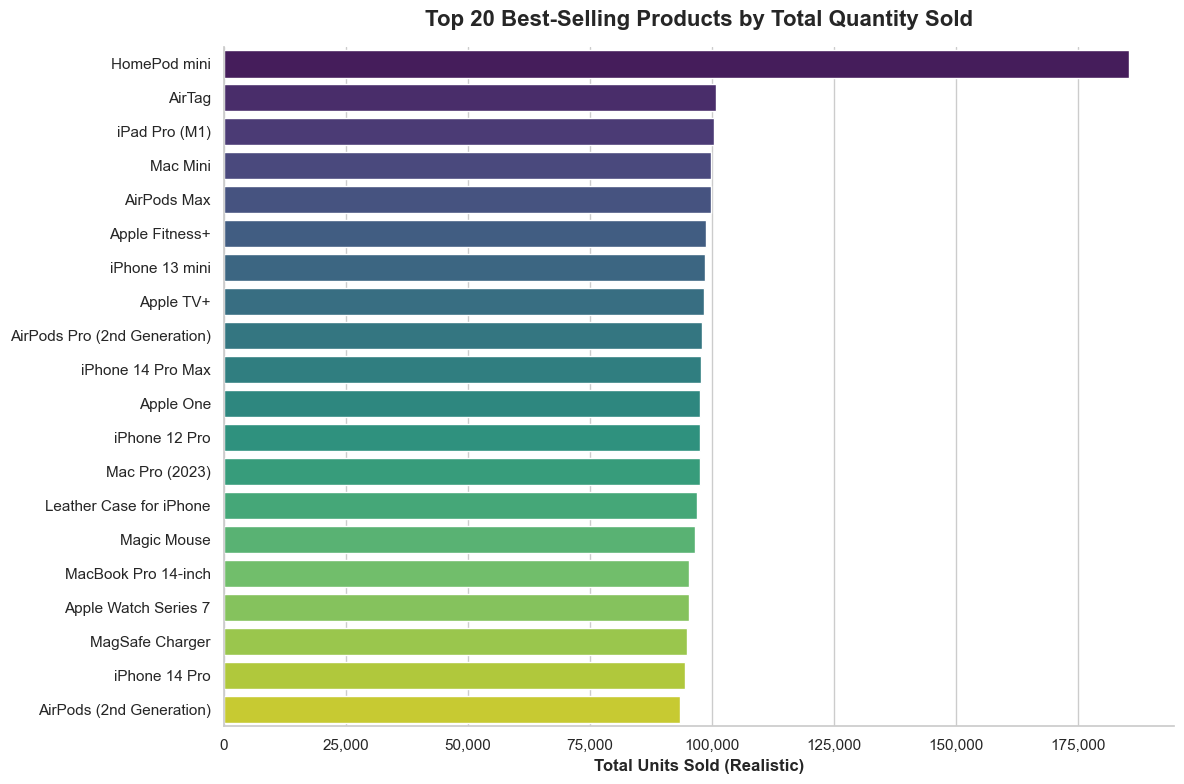

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Group by Product Name and SUM the entire quantity sold
top_products = (
    df.groupby('product_name')['quantity_realistic']
    .sum()
    .reset_index()
    .sort_values(by='quantity_realistic', ascending=False)
)

# Print out the Top 15 in a clean table format
print("=== Top 15 Best-Selling Products (By Volume) ===")
display(top_products.head(15))

# 2. Visualize the Top 20 in a Horizontal Bar Chart
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Create the Bar Chart
sns.barplot(
    data=top_products.head(20),  # Only plotting Top 20 so it's not cramped
    y='product_name', 
    x='quantity_realistic', 
    palette='viridis'            # Apple-like cool shifting colors
)

# 3. Add titles and formats
plt.title('Top 20 Best-Selling Products by Total Quantity Sold', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('', fontsize=12) # Hide the "product_name" label since it's obvious 
plt.xlabel('Total Units Sold (Realistic)', fontsize=12, fontweight='bold')

# Format the X-axis numbers with commas (e.g., 150,000)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

sns.despine()
plt.tight_layout()
plt.show()


In [102]:
df.columns

Index(['sale_id', 'sale_date', 'store_id', 'product_id', 'quantity',
       'product_name', 'launch_date', 'price', 'store_name', 'city',
       'category_id', 'category_name', 'sales_amount', 'invalid_launch_flag',
       'product_age_days', 'exchange_rate', 'inflation_rate',
       'internet_usage_pct', 'country_norm_mapped', 'year', 'gdp_type',
       'gdp_per_capita', 'season_factor', 'economic_factor', 'promo_flag',
       'promo_factor', 'price_realistic', 'days_from_start', 'product_trend',
       'trend_factor', 'store_factor', 'mu_demand', 'quantity_realistic',
       'sales_amount_realistic', 'month'],
      dtype='object')

=== Total Units Sold by Category ===


,category_name,quantity_realistic
0,Accessories,959129
5,Smartphone,946353
1,Audio,827096
8,Tablet,816191
3,Laptop,689422
9,Wearable,687012
2,Desktop,674811
7,Subscription Service,578075
6,Streaming Device,176467
4,Smart Speaker,142037


C:\Users\Ali Sherif\AppData\Local\Temp\ipykernel_18000\1945845135.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


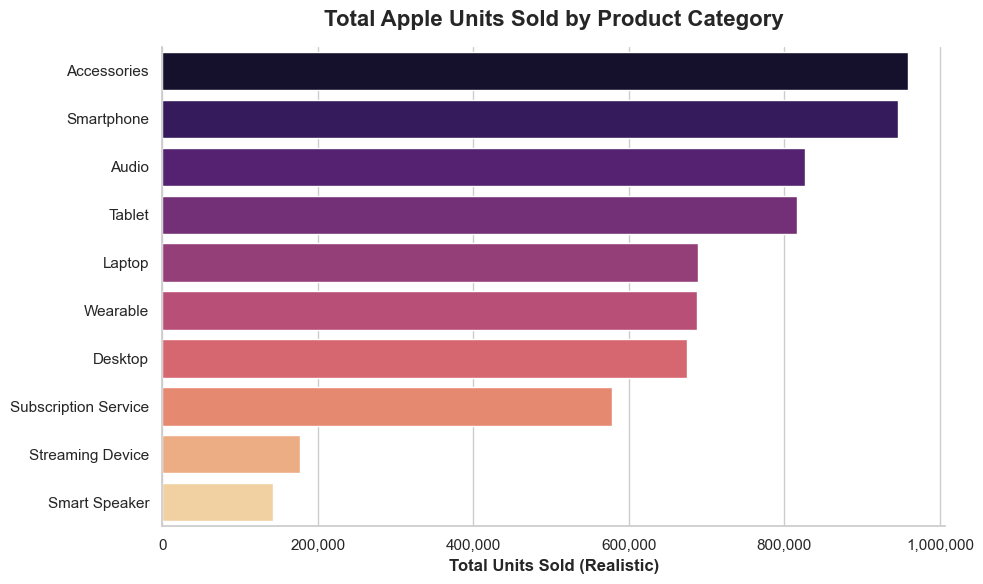

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Group by Category Name and SUM the entire quantity sold
top_categories = (
    df.groupby('category_name')['quantity_realistic']
    .sum()
    .reset_index()
    .sort_values(by='quantity_realistic', ascending=False)
)

# Print out the clean table format
print("=== Total Units Sold by Category ===")
display(top_categories)

# 2. Visualize all Categories in a Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create the Bar Chart
sns.barplot(
    data=top_categories, 
    y='category_name', 
    x='quantity_realistic', 
    palette='magma'            # Using a bold color map for categories
)

# 3. Add titles and scale formatting
plt.title('Total Apple Units Sold by Product Category', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('', fontsize=12) # Hide the label since it's obvious 
plt.xlabel('Total Units Sold (Realistic)', fontsize=12, fontweight='bold')

# Format the X-axis numbers with commas (e.g., 1,500,000)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

sns.despine()
plt.tight_layout()
plt.show()
